# [이론] 분류 모델 지표와 데이터 불균형

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🎯 분류 지표와 불균형 — 어떤 실수를 감수할지 고른다

## — 점수는 믿을 수 있게 됐습니다. 이제 *어떤 점수*를 볼지 고릅니다

---

## 📋 학습 목표

이 학습 노트북을 마치면 여러분은 다음을 할 수 있습니다.

1. **혼동행렬(Confusion Matrix)** 네 칸의 의미를 알고, 정밀도·재현율의 트레이드오프를 **"어떤 실수가 더 비싼가"** 로 설명할 수 있습니다.
2. **정밀도(Precision)·재현율(Recall)·F1**을 혼동행렬에서 직접 계산하고, 문제 맥락에 맞는 지표를 골라 근거를 댈 수 있습니다.
3. 불균형 데이터에서 **정확도가 어떻게 거짓말을 하는지** 재현하고, 정확도 90%대 모델이 실제 양성의 대부분을 놓치는 상황을 진단할 수 있습니다.
4. **ROC-AUC와 PR-AUC**의 차이를 알고, 불균형에서 PR곡선이 더 정직한 이유를 설명할 수 있습니다.
5. **임계값(Threshold)** 을 비즈니스 비용으로 정하고, `class_weight`로 클래스 불균형을 보정한 전후를 비교할 수 있습니다.

_💡 위 목록을 천천히 읽고, 지금 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해 봅시다. 노트북을 마친 뒤 다시 돌아와 비교하면 성장이 눈에 보일 것입니다._

## 📚 학습 목차

| Part | 내용                                      | 핵심 질문                                  | 예상 시간 |
| ---- | ----------------------------------------- | ------------------------------------------ | --------- |
| 0    | 오늘의 여정                               | 점수를 믿게 됐는데, 왜 지표를 또 배우는가? | 20분      |
| 1    | 혼동행렬 — 네 칸으로 쪼개 보기            | 정확도 하나가 감추는 것은 무엇인가?        | 35분      |
| 2    | 정밀도·재현율·F1 — 어떤 실수가 더 비싼가  | 두 지표는 왜 동시에 좋아지지 않는가?       | 40분      |
| 3    | 정확도의 거짓말 — 불균형 데이터           | 정확도 92%가 왜 나쁜 성적일 수 있는가?     | 35분      |
| 4    | ROC vs PR — 불균형에선 PR이 정직하다      | 같은 모델의 점수가 왜 곡선마다 다른가?     | 40분      |
| 5    | 임계값과 `class_weight` — 운영점을 고른다 | 0.5는 누가 정했는가?                       | 65분      |
| 정리 | 핵심 요약 · 실습 안내                     | 이 모델, 배포해도 되는가?                  | 15분      |
| 과제 | 오늘의 과제 · 미니과제                    | 예산이 정해져 있다면 임계값은?             | 5분       |

_⏱️ 예상 시간은 참고용입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다._

# Part 0. 오늘의 여정

## 🔁 지난 시간 복습

지난 시간에 우리는 “**이 점수를 믿어도 되는가?**”에 답했습니다.

한 번의 데이터 분할만으로 모델의 성능을 평가하면 데이터가 어떻게 나뉘었는지에 따라 결과가 달라질 수 있습니다. 그래서 **교차 검증(Cross Validation, CV)** 을 사용해 여러 학습·검증 분할에서 모델의 성능을 평가하고, 학습 데이터와 검증 데이터에서 나타나는 성능 차이를 살펴 **과적합(Overfitting)** 여부를 진단했습니다.

이제 우리는 단 한 번의 데이터 분할에 의존하지 않고, 모델의 일반화 성능을 보다 안정적으로 평가할 수 있습니다.

그런데 한 가지가 남았습니다.

회귀에서는 **MSE**와 **R²**를 살펴봤지만, 분류에서는 지금까지 주로 **정확도(Accuracy)** 하나로 모델의 성능을 평가했습니다.

과연 정확도 하나만으로 충분할까요?

## 🗺️ 오늘 배울 것

오늘의 주제를 한 문장으로 줄이면 이렇습니다.

> **정확도는 중요한 지표지만, 항상 문제의 핵심을 보여주는 것은 아닙니다.**

오늘은 먼저 정확도를 **혼동행렬(Confusion Matrix)의 네 가지 경우**로 나누어 살펴봅시다. 그러면 단순히 “몇 개를 맞혔는가?”를 넘어, **모델이 무엇을 맞혔고 무엇을 어떻게 틀렸는지** 확인할 수 있습니다.

그리고 이 네 가지 경우를 바탕으로 **정밀도(Precision)**, **재현율(Recall)**, **F1 점수(F1-score)** 를 정의해 봅시다.

다음은 오늘의 핵심 주제인 **불균형 데이터(Imbalanced Data)** 입니다.

예를 들어 전체 고객 중 이탈 고객이 10%밖에 되지 않는 상황을 생각해 봅시다. 이런 데이터에서는 정확도가 상당히 높게 나오더라도, 우리가 실제로 찾고 싶은 이탈 고객을 거의 찾지 못할 수 있습니다.

정확도가 계산상 틀린 것은 아닙니다. 문제는 **정확도만으로는 중요한 오류의 종류와 비용을 충분히 파악하기 어렵다는 것**입니다.

마지막으로 두 가지 중요한 설정을 살펴봅시다.

하나는 모델이 출력한 확률을 **예/아니오와 같은 클래스로 변환하는 기준인 임계값(Threshold)** 이고, 다른 하나는 학습 과정에서 클래스별 중요도를 다르게 반영하는 **`class_weight`** 입니다.

둘은 모두 단순히 “성능을 높이는 손잡이”라고 생각하기보다, **어떤 종류의 오류를 더 중요하게 다룰 것인지 결정하는 방법**으로 이해하는 것이 좋습니다.

> 💡 **핵심짚기**  
>
> 오늘 배우는 평가 지표는 모두 **혼동행렬의 네 가지 값에서 출발합니다.**
>
> 새로운 수학을 배우는 것이 아닙니다. 같은 네 개의 숫자를 **어떤 기준으로 나누고 해석하느냐**에 따라 정확도, 정밀도, 재현율, F1 점수가 달라집니다.
>
> 따라서 Part 1에서 혼동행렬의 네 칸을 확실하게 이해해 두면, 이후에 배우는 지표도 자연스럽게 연결할 수 있습니다.
>
> 그리고 어떤 지표를 사용해야 하는지는 통계만으로 결정되지 않습니다. **실제 문제에서 어떤 오류의 비용이 더 큰지**를 함께 고려해야 합니다.

## 🎬 오늘의 무대 — 구독 서비스 “모두플레이”의 이탈 방어

지난 시간과 같은 무대를 사용해 봅시다.

여러분은 구독형 영상 서비스 **모두플레이**의 데이터 분석가입니다. 어느 날 마케팅팀에서 다음과 같은 요청이 들어왔습니다.

> “이탈할 것 같은 고객을 미리 찾아주세요. 찾아주시면 저희가 방어 쿠폰을 보내겠습니다. 그런데 쿠폰 예산이 한정돼 있어서요. 한번 분석해주실 수 있을까요?”

이 요청에는 오늘 배울 핵심 개념이 모두 들어 있습니다.

먼저 “**이탈할 것 같은 고객을 놓치지 않고 찾고 싶다**”는 요구는 재현율과 밀접한 관련이 있습니다. 실제 이탈 고객 가운데 얼마나 많은 고객을 찾아냈는지를 중요하게 보기 때문입니다.

반면 “**쿠폰 예산이 한정돼 있다**”는 조건은 정밀도와 관련이 있습니다. 쿠폰을 보낸 고객 가운데 실제로 이탈할 고객이 얼마나 많은지를 중요하게 보기 때문입니다.

이처럼 재현율과 정밀도는 서로 다른 관점에서 모델을 평가합니다. 특히 **분류 임계값을 조정하면 두 지표 사이에 상충 관계가 나타날 수 있습니다.** 따라서 어느 한 지표를 무조건 높이는 것이 아니라, 비즈니스 상황에서 어떤 오류를 더 감수할 수 있는지 판단해야 합니다.

오늘은 이 판단을 **숫자와 근거를 바탕으로 내리는 방법**을 배워 봅시다.

실습에서는 **구독자 한 세트**를 쓰고, 대신 이탈의 **정의**를 두 가지로 두어 비교합니다.

첫 번째 정의는 **90일 안에 해지**입니다. 이 기준에서는 이탈 고객이 약 33%라 한쪽으로 크게 기울지 않으므로, 혼동행렬과 각 평가 지표의 의미를 또렷하게 살펴볼 수 있습니다.

두 번째 정의는 **30일 안에 해지**입니다. 같은 고객, 같은 행동인데 기준을 좁히기만 하면 이탈 고객이 약 10%로 줄어듭니다. 이렇게 만들어진 **불균형** 상황에서 정확도만 확인하면 어떤 문제가 생기는지 직접 확인해 봅시다.

데이터의 열 이름은 지난 시간과 동일하게 구성되어 있습니다.

## 🤖 오늘의 AI 활용 규칙 — 검증 단계

오늘부터는 AI에게 코드를 질문해 봅시다. 다만 **코드를 생성하는 것과 그 코드를 올바르게 사용하는 것은 별개의 문제**라는 점을 기억해야 합니다.

다음과 같은 작업은 AI의 도움을 받아도 좋습니다.

- **허용:** 평가 지표를 계산하는 코드, 곡선을 그리는 코드, 문법이나 오류 해결 방법을 AI에게 질문하기
- **의무:** AI가 작성하거나 제안한 코드를 **직접 검증하기**
- **주의:** 특히 오늘처럼 분류 평가 지표를 다루는 경우에는 양성 클래스의 정의, `average` 옵션, 임계값 설정 등이 문제의 맥락에 맞는지 확인하기
- **판단은 여러분의 몫:** 어떤 평가 지표를 사용할지, 임계값을 어디에 설정할지는 **비즈니스의 목적과 오류의 비용**을 고려해 결정하기

AI는 코드를 작성하는 데 도움을 줄 수 있지만, **여러분의 문제에서 어떤 오류가 더 중요한지는 스스로 판단해야 합니다.**

> 💡 **핵심짚기**  
>
> AI가 작성한 코드를 사용할 때는 다음 세 가지 질문을 던져 봅시다.
>
> ① **왜** 이렇게 작성했는가?  
> ② **어디에서** 잘못된 결과가 나올 수 있는가?  
> ③ 이 결과를 **왜 믿을 수 있는가?**
>
> 이 세 질문에 답할 수 있다면 코드를 단순히 복사해 사용하는 것이 아니라, **코드를 이해하고 검증하면서 활용하고 있는 것**입니다.

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의하기**  
>
> 코드 셀은 반드시 위에서부터 순서대로 실행해야 합니다. 앞에서 생성한 변수나 객체를 뒤의 코드에서 사용하기 때문입니다. 중간의 코드 셀부터 실행하면 필요한 변수가 생성되지 않아 오류가 발생할 수 있습니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

In [2]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 오늘 쓰는 도구를 미리 불러옵니다 (순서 실행 안전)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
)

# 재현성: 같은 난수를 항상 같게 만듭니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료!")
import sklearn
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

ModuleNotFoundError: No module named 'sklearn'

이제 오늘 쓸 데이터를 만들어 둡니다. 구독자는 **한 세트(3,000명)** 이고, 이탈의 정의만 **90일 기준**과 **30일 기준** 두 가지로 답니다. 이후 모든 Part가 이 한 세트를 가져다 씁니다.

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

In [ ]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 실습 데이터 준비 — 모두플레이 구독자 3,000명 + 이탈 정의 2종(90일 / 30일)
# (실행하면 두 정의의 이탈 비율이 출력됩니다)
# ─────────────────────────────────────────────
# 열 이름은 지난 시간들과 같습니다. 이탈 비율을 우리가 정해야
# '정확도의 거짓말'을 시연할 수 있으므로 합성으로 만듭니다
FEATURES = ["tenure_months", "watch_hours_last_month", "avg_daily_watch_min",
            "avg_session_min", "days_since_last_watch", "titles_started",
            "completion_rate", "support_tickets", "device_count", "monthly_fee"]

# 이탈 판정의 기준선(절편) — 작을수록 이탈로 판정되는 고객이 줄어듭니다
BASE_90D = 1.15       # "90일 안에 해지" → 이탈률 약 33%
BASE_30D = -1.188     # "30일 안에 해지" → 이탈률 약 10%


def make_moduplay(n=3000, seed=RANDOM_STATE, churn_base=BASE_30D):
    """모두플레이 구독자 데이터. 같은 고객에게 이탈 라벨을 여러 개 답니다.

    churn_90d / churn_30d — "언제까지 해지하면 이탈로 볼 것인가"의 차이입니다.
    churn — churn_base로 비율을 직접 지정한 라벨. (실무에서는 pd.read_csv 자리)
    """
    rng = np.random.default_rng(seed)
    engagement = rng.beta(2.2, 2.2, n)      # 서비스에 붙어 있는 정도(관측 불가)

    tenure = rng.integers(1, 49, n)
    watch_h = np.clip(rng.normal(5 + 40 * engagement, 5.5, n), 0.3, None)
    avg_daily = np.clip(watch_h * 60 / 30 + rng.normal(0, 2.0, n), 0.5, None)
    avg_session = np.clip(rng.normal(18 + 75 * engagement, 11, n), 4, None)
    days_since = np.clip(rng.poisson(0.8 + 17 * (1 - engagement) ** 1.5, n), 0, 30)
    titles = rng.poisson(1.5 + 24 * engagement, n)
    completion = np.clip(rng.normal(0.22 + 0.55 * engagement, 0.11, n), 0.02, 1.0)
    tickets = rng.poisson(0.25 + 1.3 * (1 - engagement), n)
    devices = 1 + rng.binomial(3, 0.15 + 0.55 * engagement, n)
    fee = rng.choice([9900, 14900, 19900], n, p=[0.45, 0.35, 0.20])

    df = pd.DataFrame({
        "tenure_months": tenure,
        "watch_hours_last_month": watch_h.round(1),
        "avg_daily_watch_min": avg_daily.round(1),
        "avg_session_min": avg_session.round(1),
        "days_since_last_watch": days_since,
        "titles_started": titles,
        "completion_rate": completion.round(3),
        "support_tickets": tickets,
        "device_count": devices,
        "monthly_fee": fee,
    })

    # 이탈 위험 점수 — 기준선을 뺀 나머지. 모든 정의가 이 점수를 공유합니다
    risk = (0.175 * df["days_since_last_watch"]
            - 0.070 * df["watch_hours_last_month"]
            - 2.10 * df["completion_rate"]
            + 0.38 * df["support_tickets"]
            - 0.028 * df["tenure_months"]
            - 0.20 * df["device_count"]
            + rng.normal(0, 0.55, n))

    # 동전 하나를 여러 정의가 함께 씁니다
    # → 30일 안에 해지한 고객은 90일 안에도 반드시 해지한 것이 됩니다(포함관계 보장)
    coin = rng.random(n)

    def judge(base):
        return (coin < 1 / (1 + np.exp(-(base + risk)))).astype(int)

    df["churn_90d"] = judge(BASE_90D)
    df["churn_30d"] = judge(BASE_30D)
    df["churn"] = judge(churn_base)
    return df


moduplay = make_moduplay()

# 학습/테스트 분리는 한 번만 합니다 — 두 정의가 똑같은 고객 분할을 공유합니다
train_df, test_df = train_test_split(
    moduplay, test_size=0.25, random_state=RANDOM_STATE,
    stratify=moduplay["churn_30d"])          # 더 희귀한 정의에 맞춰 계층 분할

X_tr, X_te = train_df[FEATURES], test_df[FEATURES]
y90_tr, y90_te = train_df["churn_90d"], test_df["churn_90d"]   # Part 1~2에서 씁니다
y_tr, y_te = train_df["churn_30d"], test_df["churn_30d"]       # Part 3~5에서 씁니다
X, y = moduplay[FEATURES], moduplay["churn_30d"]

print(f"모두플레이 구독자 {len(moduplay):,}명 | 학습 {len(train_df):,} / 테스트 {len(test_df)}")
print()
print("[정의 A] 90일 안에 해지 = 이탈")
print(f"    이탈 비율 {moduplay['churn_90d'].mean():.3f}   (테스트 이탈 {int(y90_te.sum())}명)")
print("[정의 B] 30일 안에 해지 = 이탈")
print(f"    이탈 비율 {moduplay['churn_30d'].mean():.3f}   (테스트 이탈 {int(y_te.sum())}명)")
print()
broken = int(((moduplay["churn_30d"] == 1) & (moduplay["churn_90d"] == 0)).sum())
print(f"30일 이탈자인데 90일 이탈자가 아닌 사람: {broken}명 (0이어야 정상입니다)")
print("→ 같은 고객, 같은 행동입니다. 정의만 좁혔더니 이탈이 33%에서 10%로 줄었습니다.")

모두플레이 구독자 3,000명 | 학습 2,250 / 테스트 750

[정의 A] 90일 안에 해지 = 이탈
    이탈 비율 0.330   (테스트 이탈 241명)
[정의 B] 30일 안에 해지 = 이탈
    이탈 비율 0.100   (테스트 이탈 75명)

30일 이탈자인데 90일 이탈자가 아닌 사람: 0명 (0이어야 정상입니다)
→ 같은 고객, 같은 행동입니다. 정의만 좁혔더니 이탈이 33%에서 10%로 줄었습니다.


# Part 1. 혼동행렬 — 네 칸으로 쪼개 보기

정확도는 전체 예측 중 맞힌 비율을 숫자 하나로 요약합니다. 그러나 이 요약만으로는 **서로 다른 오류의 종류와 크기를 구분할 수 없습니다.**

병을 놓친 것과 건강한 사람을 환자로 오진한 것은 완전히 다른 실수입니다. 이탈할 고객을 놓친 것과 떠나지 않을 고객에게 쿠폰을 낭비한 것도 다른 실수입니다. 정확도만으로는 이 둘을 구분할 수 없습니다.

> ❓ **질문하기**  
> 정확도라는 숫자 하나가 감추고 있는 것은 정확히 무엇인가?

## 💡 쉽게 말하면 — 오답노트를 펼쳐 보기

시험에서 80점을 받았다고 가정합니다. 이 숫자만으로는 무엇을 공부해야 할지 알 수 없습니다. 하지만 **오답노트**를 펼치면 달라집니다. "계산 실수 3개, 개념 착각 2개"처럼 *어떤 종류의 실수*를 했는지 보이고, 그때부터 공부 방향이 정해집니다.

**혼동행렬(Confusion Matrix)** 이 분류 모델의 오답노트입니다. 모델의 예측을 네 칸으로 쪼개 놓은 표입니다.

|                    | 모델: "이탈한다"(1) | 모델: "안 한다"(0) |
| ------------------ | ------------------- | ------------------ |
| **실제로 이탈(1)** | 잘 맞힘 ✅          | **놓침** ❌        |
| **실제로 유지(0)** | **헛경보** ❌       | 잘 맞힘 ✅         |

대각선은 맞힌 것이고, 나머지 두 칸이 **서로 다른 두 종류의 실수**입니다. 정확도는 이 네 칸을 `(맞힌 것) / (전체)`로 합쳐 계산한 숫자입니다.

## 🔍 자세히 알아보기 — 네 칸의 정식 이름

네 칸에는 정해진 이름이 있습니다. 이름 규칙은 단순합니다 — **뒷글자가 모델의 예측, 앞글자가 그 예측이 맞았는지**입니다.

| 약어   | 정식 이름                  | 뜻                           | 모두플레이에서는                        |
| ------ | -------------------------- | ---------------------------- | --------------------------------------- |
| **TP** | True Positive (참 양성)    | 양성이라 예측하고 **맞음**   | 이탈할 고객을 제대로 찾음               |
| **FP** | False Positive (거짓 양성) | 양성이라 예측했지만 **틀림** | 안 떠날 고객에게 쿠폰 낭비 (**헛경보**) |
| **FN** | False Negative (거짓 음성) | 음성이라 예측했지만 **틀림** | 이탈할 고객을 못 잡음 (**놓침**)        |
| **TN** | True Negative (참 음성)    | 음성이라 예측하고 **맞음**   | 유지할 고객을 제대로 넘김               |

읽는 법: **P/N은 모델이 무엇이라 예측했는지**, **True/False는 그 예측이 맞았는지**입니다. 그래서 FN은 "음성이라 했는데 틀렸다" = 실제로는 양성이었다는 뜻입니다.

정확도는 이렇게 정의됩니다.

$$\text{정확도} = \frac{TP + TN}{TP + FP + FN + TN}$$

- $TP + TN$ — 맞힌 개수 (대각선)
- 분모 — 전체 개수

분자가 대각선 두 칸의 **합**이라는 점이 핵심입니다. FP와 FN이 각각 몇인지는 이 식에서 사라집니다. **정확도는 두 실수를 구분하지 않습니다.**

> ⚠️ **주의하기**  
> 혼동행렬을 출력할 때 행과 열의 순서를 반대로 읽는 실수가 매우 흔합니다. scikit-learn의 `confusion_matrix`는 **행 = 실제, 열 = 예측**이고, 값이 작은 클래스(0)가 먼저 옵니다. 즉 `[[TN, FP], [FN, TP]]` 순서입니다. 헷갈릴 때는 `.ravel()`로 펼쳐 `tn, fp, fn, tp` 순으로 받으면 안전합니다.

> 📌 **실무 연결하기**  
> 이 네 칸은 **의료**에서 진단 놓침 대 과잉진단, **금융**에서 사기 미탐지 대 정상거래 차단, **제조**에서 불량 유출 대 양품 폐기, **보안**에서 침입 미탐지 대 오탐 경보로 똑같이 쓰입니다. 산업이 달라도 "두 종류의 실수"라는 구조는 같습니다.

## 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬

먼저 **90일 정의**의 혼동행렬을 확인합니다. 이탈 고객이 약 33%이므로 다수 클래스가 정확도에 미치는 영향이 30일 정의보다 작습니다. Part 3에서는 양성 비율이 약 10%로 낮아질 때 정확도만으로 판단하기 어려운 이유를 살펴봅니다.

> 🤔 **예상하기**  
> 90일 정의에서 이탈 고객은 약 33%입니다. 로지스틱 회귀를 학습시키면 정확도가 얼마쯤 나올까요? 그리고 네 칸 중 **틀린 두 칸(FP·FN)** 에는 각각 몇 개쯤 들어갈 것 같습니까?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

In [ ]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬
# 90일 정의로 학습 → 혼동행렬 네 칸 (실행하면 TN·FP·FN·TP가 출력됩니다)
# ─────────────────────────────────────────────
# 로지스틱 회귀는 피처 크기에 민감하므로 스케일 조정과 묶어 학습합니다
model_90 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
).fit(X_tr, y90_tr)

pred_90 = model_90.predict(X_te)

cm_90 = confusion_matrix(y90_te, pred_90)
tn, fp, fn, tp = cm_90.ravel()      # 순서 주의: TN, FP, FN, TP

print("혼동행렬 (행=실제, 열=예측)")
print(cm_90)
print()
print(f"  TP(이탈을 제대로 찾음) = {tp}")
print(f"  FP(헛경보)             = {fp}")
print(f"  FN(놓침)               = {fn}")
print(f"  TN(유지를 제대로 넘김) = {tn}")
print()
print(f"→ 정확도 = (TP+TN)/전체 = ({tp}+{tn})/{len(y90_te)} = {accuracy_score(y90_te, pred_90):.3f}")
print(f"  틀린 것은 {fp + fn}개이고, 헛경보 {fp}개와 놓침 {fn}개로 나뉩니다.")

혼동행렬 (행=실제, 열=예측)
[[448  61]
 [ 74 167]]

  TP(이탈을 제대로 찾음) = 167
  FP(헛경보)             = 61
  FN(놓침)               = 74
  TN(유지를 제대로 넘김) = 448

→ 정확도 = (TP+TN)/전체 = (167+448)/750 = 0.820
  틀린 것은 135개이고, 헛경보 61개와 놓침 74개로 나뉩니다.


> 🎯 **[C3] 확인하기**  
> 정확도 **0.820**입니다. 그런데 틀린 것이 **135개**나 됩니다 — 헛경보(FP) 61개, 놓침(FN) 74개. 두 실수의 크기가 서로 다르고, **놓침이 헛경보보다 많습니다.**

정확도 0.820은 이 숫자만 보면 양호해 보일 수 있습니다. 하지만 네 칸을 열어 보니 **이탈할 고객 74명을 놓쳤다**는 사실이 드러납니다. 정확도라는 한 숫자만 봤다면 이 74명은 끝까지 보이지 않았습니다.

이번엔 같은 네 칸을 **그림**으로 봅니다. 숫자 네 개보다 색이 입혀진 격자가 훨씬 빨리 읽힙니다.

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

→ 대각선(왼쪽 위 ↘ 오른쪽 아래)이 맞힌 칸, 나머지 두 칸이 서로 다른 두 실수입니다.


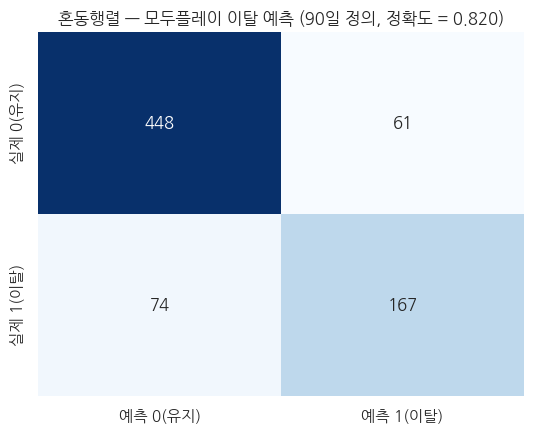

In [ ]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬
# 혼동행렬 히트맵 (실행하면 네 칸이 색으로 구분된 격자가 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_90, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title("혼동행렬 — 모두플레이 이탈 예측 (90일 정의, "
             f"정확도 = {accuracy_score(y90_te, pred_90):.3f})")
plt.tight_layout()
plt.show()

print("→ 대각선(왼쪽 위 ↘ 오른쪽 아래)이 맞힌 칸, 나머지 두 칸이 서로 다른 두 실수입니다.")

> 👀 **[C4] 결과읽기**  
> 진한 칸이 개수가 많은 칸입니다. 왼쪽 위 TN(448)이 가장 진하고 오른쪽 아래 TP(167)가 그다음입니다. 대각선이 진하고 나머지 두 칸이 옅으면 좋은 모델입니다. 분류 모델을 평가할 때는 정확도와 함께 혼동행렬을 확인해야 오류의 종류를 구분할 수 있습니다.

> ⚠️ **주의하기**  
> 분류에서 **양성(Positive)** 은 "좋은 일"이라는 뜻이 아닙니다. **찾으려는 대상**을 가리키는 말입니다. 오늘 무대에서 양성(`y=1`)은 **이탈**이고, 이탈은 회사에 나쁜 일입니다. 의료에서 양성이 "질병을 발견함"을 뜻하는 것과 같은 구조입니다 — 좋고 나쁨이 아니라 **어느 클래스를 찾도록 정의했는가**를 기준으로 읽습니다.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
1) [C3]에서 얻은 `tn`, `fp`, `fn`, `tp` 네 변수로 정확도를 직접 계산합니다.
   (accuracy_score를 쓰지 말고 네 칸의 나눗셈으로만)
2) 계산한 값이 `accuracy_score(y90_te, pred_90)`와 같은지 확인합니다.
3) 만약 이 모델이 FN(놓침)만 40개 더 늘고 TP가 40개 줄었다고 가정하면,
   정확도와 재현율(TP/(TP+FN))은 각각 얼마가 될까요?
   어느 쪽이 더 크게 반응합니까?
```

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

In [ ]:
# [C5] Part 1 · ⌨️ 백문이 불여일타! (1)
# ⌨️ 백문이 불여일타! (1) — 네 칸으로 정확도 직접 계산

# (tn, fp, fn, tp 는 [C3]에서 만들어 둔 그대로입니다)

# 여기에 코드를 작성하세요

# sum( fp, fn ) / sum(tn, fp, fn, tp )

# ─────────────────────────────────────────────
# 1) tn, fp, fn, tp로 정확도 직접 계산 (accuracy_score 없이)
# ─────────────────────────────────────────────
total = tn + fp + fn + tp
accuracy_manual = (tp + tn) / total

print(f"직접 계산한 정확도 = ({tp}+{tn})/{total} = {accuracy_manual:.3f}")

# ─────────────────────────────────────────────
# 2) accuracy_score와 비교
# ─────────────────────────────────────────────
accuracy_sklearn = accuracy_score(y90_te, pred_90)
print(f"sklearn 정확도       = {accuracy_sklearn:.3f}")
print(f"두 값이 같은가?       = {np.isclose(accuracy_manual, accuracy_sklearn)}")

# ─────────────────────────────────────────────
# 3) FN +40, TP -40 가정 시나리오
# ─────────────────────────────────────────────
fn_new = fn + 40
tp_new = tp - 40

accuracy_new = (tp_new + tn) / total
recall_old = tp / (tp + fn)
recall_new = tp_new / (tp_new + fn_new)

print(f"\n[변경 전] 정확도 = {accuracy_manual:.3f}, 재현율 = {recall_old:.3f}")
print(f"[변경 후] 정확도 = {accuracy_new:.3f}, 재현율 = {recall_new:.3f}")

print(f"\n정확도 변화량 = {accuracy_new - accuracy_manual:+.3f}")
print(f"재현율 변화량 = {recall_new - recall_old:+.3f}")

직접 계산한 정확도 = (167+448)/750 = 0.820
sklearn 정확도       = 0.820
두 값이 같은가?       = True

[변경 전] 정확도 = 0.820, 재현율 = 0.693
[변경 후] 정확도 = 0.767, 재현율 = 0.527

정확도 변화량 = -0.053
재현율 변화량 = -0.166


<details>
<summary>(클릭) 💡 힌트</summary>

- 정확도의 정의는 `(맞힌 개수) / (전체 개수)`이고, 맞힌 개수는 대각선 두 칸의 합입니다.
- 전체 개수는 네 칸을 모두 더한 값입니다 — `len(y90_te)`와 같아야 합니다.
- 3번은 `fn + 40`, `tp - 40`으로 값을 바꿔 같은 식에 넣어 계산합니다. 재현율은 분모가 `tp + fn`입니다.

</details>

## 🚦 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어갑니다. 틀려도 괜찮습니다.

1. 혼동행렬의 네 칸 이름(TP·FP·FN·TN)을 각각 한 문장으로 풀어 설명할 수 있습니까?
2. 정확도 식에서 FP와 FN이 왜 구분되지 않는지 설명할 수 있습니까?
3. 모두플레이에서 FN(놓침)과 FP(헛경보)는 각각 어떤 비즈니스 손실로 이어집니까?

> ⏭️ **다음 학습 예고**  
> 네 칸을 갖췄습니다. 그런데 네 칸을 매번 눈으로 읽는 것은 번거롭고, 모델끼리 비교하기도 어렵습니다. 다음 Part에서는 이 네 칸을 **한 방향씩 나눠** 정밀도·재현율이라는 두 개의 숫자로 요약합니다. 그리고 같은 모델의 임계값을 조정할 때 두 지표 사이에 흔히 나타나는 **상충 관계**를 살펴봅니다.

# Part 2. 정밀도·재현율·F1 — 어떤 실수가 더 비싼가

네 칸을 그대로 두면 모델을 비교하기 어렵습니다. 그래서 네 칸을 **두 방향으로 나눠** 요약합니다. 그런데 이 나눗셈에는 깊은 뜻이 있습니다 — **두 방향은 각각 다른 사람의 질문에 답합니다.**

- 마케팅팀의 질문: "쿠폰 보낸 사람 중 진짜 이탈할 사람이 몇 %였나요?" → **정밀도**
- 경영진의 질문: "떠난 고객 중 우리가 미리 잡아낸 사람이 몇 %인가요?" → **재현율**

> ❓ **질문하기**  
> 같은 모델의 임계값을 바꿀 때 정밀도와 재현율은 어떻게 변하며, 운영점은 무엇을 기준으로 고르는가?

## 💡 쉽게 말하면 — 그물의 크기를 정하는 문제

물고기를 잡는 상황을 가정합니다. 강에 특정 종류의 물고기가 있고, 우리는 그것만 잡고 싶습니다.

**그물을 크게 던지면** — 목표 물고기는 거의 다 잡힙니다(재현율↑). 그런데 잡은 것 중에 돌멩이와 잡초도 많이 섞입니다(정밀도↓).

**그물을 작게 던지면** — 잡은 것은 거의 다 목표 물고기입니다(정밀도↑). 그런데 놓친 물고기가 많습니다(재현율↓).

여기서 중요한 것은 **어느 쪽이 옳은 답이 아니라는 점**입니다. 물고기 한 마리를 놓치는 손실이 큰지, 돌멩이를 건져 올리는 비용이 큰지에 따라 답이 갈립니다. **오류의 비용과 운영 조건이 우선순위를 정합니다.**

![정밀도와 재현율의 관계 — 전체 중 실제 양성인 영역과 모델이 양성이라 예측한 원이 겹치는 부분이 참 양성이고, 원 안의 나머지가 거짓 양성, 원 밖의 실제 양성이 거짓 음성이다](https://upload.wikimedia.org/wikipedia/commons/2/26/Precisionrecall.svg)

_(출처: [Precisionrecall](https://commons.wikimedia.org/wiki/File:Precisionrecall.svg) — Walber, CC BY-SA 4.0)_

> 🧭 **한눈에 보기**  
> 왼쪽 절반이 **실제 양성**인 영역이고, 가운데 **원이 모델이 "양성"이라 예측한 것**입니다. 원 안의 왼쪽(초록)이 TP, 원 안의 오른쪽(빨강)이 FP, 원 밖의 왼쪽이 FN입니다. **정밀도는 원을 분모로 하는 비율**(원 안에서 얼마나 정확했나)이고, **재현율은 왼쪽 절반을 분모로 하는 비율**(찾아야 할 것 중 얼마나 찾았나)입니다. 원을 키우면 초록이 늘지만 빨강도 늘어납니다 — 그것이 트레이드오프입니다.

## 🔍 자세히 알아보기 — 두 개의 나눗셈, 그리고 그 조화평균

**정밀도(Precision)** — 모델이 양성이라 한 것 중 실제 양성의 비율입니다. **분모가 예측**입니다.

$$\text{정밀도} = \frac{TP}{TP + FP}$$

직관: "내가 지목한 것들, 얼마나 믿을 수 있나?" 분모가 모델의 예측이므로, 헛경보(FP)가 늘면 떨어집니다.

**재현율(Recall)** — 실제 양성 중 모델이 찾아낸 비율입니다. **분모가 실제**입니다.

$$\text{재현율} = \frac{TP}{TP + FN}$$

직관: "찾아야 할 것들, 얼마나 놓치지 않았나?" 분모가 실제 양성이므로, 놓침(FN)이 늘면 떨어집니다.

두 식의 **분자는 같고 분모만 다릅니다.** 정밀도는 FP를, 재현율은 FN을 벌점으로 받습니다. 같은 모델에서 임계값을 조정하면 한쪽을 높이는 대신 다른 쪽이 낮아지는 경향이 나타납니다. 다만 모델이나 피처 자체가 개선되면 두 지표가 함께 좋아질 수도 있습니다.

**F1** — 두 지표를 하나로 합쳐야 할 때 쓰는 값입니다.

$$F_1 = 2 \times \frac{\text{정밀도} \times \text{재현율}}{\text{정밀도} + \text{재현율}}$$

- 이것은 산술평균이 아니라 **조화평균(Harmonic Mean)** 입니다.
- 조화평균은 **둘 중 낮은 쪽에 끌려갑니다.** 정밀도 1.0·재현율 0.0이면 산술평균은 0.5지만 F1은 **0**입니다.
- 직관: "한쪽만 잘해서는 점수를 못 받는다." 따라서 F1은 두 지표 중 한쪽만 높은 경우에 낮은 값을 부여합니다. 다만 실제 오류 비용이 서로 다를 때는 F1만으로 운영 결정을 내리기 어렵습니다.

### 무엇을 골라야 하나 — 비용이 정한다

지표 선택의 첫 질문은 통계 질문이 아닙니다. **"이 문제에서 어떤 실수가 더 비싼가?"** 입니다.

| 상황                | 더 비싼 실수    | 우선할 지표       | 이유                                     |
| ------------------- | --------------- | ----------------- | ---------------------------------------- |
| 암 진단 선별검사    | 놓침(FN)        | **재현율**        | 놓치면 생명, 헛경보는 재검사로 회수 가능 |
| 스팸 메일 자동 삭제 | 헛경보(FP)      | **정밀도**        | 중요 메일이 삭제되면 회수 불가           |
| 금융 사기 탐지      | 놓침(FN)        | **재현율**        | 미탐지 피해가 오탐 심사 비용보다 큼      |
| 채용 서류 자동 탈락 | 헛경보(FP)      | **정밀도**        | 좋은 지원자를 잘못 걸러내면 손실이 큼    |
| 이탈 방어 쿠폰      | **상황에 따라** | 비용·용량 기반 판단 | 쿠폰 단가와 고객 생애가치의 비율에 달림  |

> 💡 **핵심짚기**  
> 정밀도와 재현율 가운데 하나가 항상 더 좋은 것은 아닙니다. 먼저 **"이 문제에서 어떤 실수가 더 비싼가"** 를 확인하고, 그 답에 맞는 지표와 운영 조건을 선택합니다.

> 📌 **실무 연결하기**  
> 같은 구조가 **보안**(침입 탐지는 재현율 우선), **이커머스**(추천은 정밀도 우선 — 엉뚱한 추천은 신뢰를 깎음), **제조**(안전 부품 검사는 재현율 우선), **마케팅**(예산이 빡빡할수록 정밀도 우선)에 그대로 적용됩니다.

## 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산

식을 외우는 것보다 **네 칸에서 직접 나눠 보는 것**이 훨씬 오래 남습니다. [C3]에서 얻은 네 칸으로 정밀도·재현율·F1을 손계산하고, scikit-learn의 값과 대조합니다.

> 🤔 **예상하기**  
> [C3]의 네 칸은 TN=448, FP=61, FN=74, TP=167이었습니다. 놓침(FN 74)이 헛경보(FP 61)보다 **더 많습니다.** 그렇다면 정밀도와 재현율 중 어느 쪽이 낮게 나올까요? 그리고 F1은 그 둘과 비교해 어디쯤 놓일까요?

▶️ **코드 실행하기 · 코드 셀 6 [C6]**

In [ ]:
# ─────────────────────────────────────────────
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산
# 정밀도·재현율·F1을 정의대로 계산 → sklearn 결과와 대조 (실행하면 두 값이 나란히 출력됩니다)
# ─────────────────────────────────────────────
# 손계산 — 정의 그대로
precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print("네 칸:", f"TN={tn} FP={fp} FN={fn} TP={tp}")
print()
print(f"정밀도 = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision_manual:.4f}")
print(f"재현율 = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall_manual:.4f}")
print(f"F1     = 2PR/(P+R)                = {f1_manual:.4f}")
print()
print("sklearn 값과 대조")
print(f"  precision_score = {precision_score(y90_te, pred_90):.4f}")
print(f"  recall_score    = {recall_score(y90_te, pred_90):.4f}")
print(f"  f1_score        = {f1_score(y90_te, pred_90):.4f}")
print()
print("→ 손계산과 sklearn이 정확히 일치합니다. 지표는 네 칸의 나눗셈일 뿐입니다.")

네 칸: TN=448 FP=61 FN=74 TP=167

정밀도 = TP/(TP+FP) = 167/(167+61) = 0.7325
재현율 = TP/(TP+FN) = 167/(167+74) = 0.6929
F1     = 2PR/(P+R)                = 0.7122

sklearn 값과 대조
  precision_score = 0.7325
  recall_score    = 0.6929
  f1_score        = 0.7122

→ 손계산과 sklearn이 정확히 일치합니다. 지표는 네 칸의 나눗셈일 뿐입니다.


> 🎯 **[C6] 확인하기**  
> 정밀도 **0.7325**, 재현율 **0.6929**입니다. 예상대로 **재현율이 더 낮습니다** — 정밀도가 받는 벌점은 FP(61)이고 재현율이 받는 벌점은 FN(74)인데, FN이 더 많으니까요. F1은 **0.7122**로 두 값 사이에 놓입니다.

두 값이 서로 가까울 때는 조화평균도 산술평균과 거의 같습니다(산술평균 0.7127 대 F1 0.7122). 조화평균의 진짜 성격은 **두 값이 크게 벌어질 때** 드러납니다 — Part 3에서 재현율이 0.320까지 떨어질 때 F1이 어떻게 되는지 보게 됩니다.

한 가지 편리한 도구를 더 소개합니다. `classification_report`는 앞서 계산한 지표들을 클래스별로 한 번에 표로 만들어 줍니다.

▶️ **코드 실행하기 · 코드 셀 7 [C7]**

In [ ]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산
# classification_report — 클래스별 지표를 한 표로 (실행하면 지표 표가 출력됩니다)
# ─────────────────────────────────────────────
print(classification_report(
    y90_te, pred_90,
    target_names=["0 (유지)", "1 (이탈)"],
    digits=3,
))
print("support = 각 클래스의 실제 개수입니다. 지표를 해석할 때 반드시 함께 보세요.")

              precision    recall  f1-score   support

      0 (유지)      0.858     0.880     0.869       509
      1 (이탈)      0.732     0.693     0.712       241

    accuracy                          0.820       750
   macro avg      0.795     0.787     0.791       750
weighted avg      0.818     0.820     0.819       750

support = 각 클래스의 실제 개수입니다. 지표를 해석할 때 반드시 함께 보세요.


> 👀 **[C7] 결과읽기**  
> 각 행이 **클래스별** 지표입니다. `1 (이탈)` 행의 precision·recall이 방금 손계산한 값입니다. `0 (유지)` 행은 **관점을 뒤집어** 유지 고객을 찾는 문제로 본 지표입니다 — 같은 혼동행렬에서 계산 방향만 바꾼 것입니다. 유지 쪽 점수가 더 높은 이유는 그 클래스가 두 배 이상 많기 때문입니다(support 509 대 241).

맨 오른쪽 `support` 열도 함께 확인합니다. 각 클래스의 실제 개수입니다. **support가 아주 작은 클래스의 지표는 몇 개 차이로 크게 흔들립니다** — 지표 숫자만 보고 판단하면 안 되는 이유입니다.

> ➕ **심화 학습하기**  
> 표 아래의 `macro avg`는 클래스별 지표를 **개수와 무관하게 단순 평균**한 값이고, `weighted avg`는 **support로 가중 평균**한 값입니다. 불균형 데이터에서 이 둘은 크게 벌어집니다 — 각 클래스를 같은 비중으로 요약하려면 `macro avg`를, 실제 클래스 빈도를 반영해 전체 경향을 요약하려면 `weighted avg`를 확인합니다. 두 평균 모두 클래스별 지표를 대신하지는 않습니다.

## ⌨️ 백문이 불여일타! (2)

```
[문제]
1) 아래 가상의 혼동행렬 두 개를 각각 손으로 계산해 정밀도·재현율·F1을 구합니다.
   모델 A: TP=90, FP=10, FN=10, TN=890
   모델 B: TP=50, FP=0,  FN=50, TN=900
2) 두 모델의 정확도를 각각 구합니다. 정확도로는 어느 쪽이 더 좋아 보입니까?
3) 만약 이것이 "암 진단 선별검사"라면 어느 모델을 택해야 할까요? 이유를 한 줄로 적습니다.
```

▶️ **코드 실행하기 · 코드 셀 8 [C8]**

In [ ]:
# [C8] Part 2 · ⌨️ 백문이 불여일타! (2)
# ⌨️ 백문이 불여일타! (2) — 두 모델을 지표로 비교하고 상황에 맞게 선택

A = {"tp": 90, "fp": 10, "fn": 10, "tn": 890}
B = {"tp": 50, "fp": 0,  "fn": 50, "tn": 900}

# 여기에 코드를 작성하세요

<details>
<summary>(클릭) 💡 힌트</summary>

- 딕셔너리에서 값을 꺼내 같은 식에 넣는 함수를 하나 만들면 두 모델을 반복 없이 처리할 수 있습니다.
- 정밀도의 분모는 `tp + fp`, 재현율의 분모는 `tp + fn`입니다.
- 모델 B는 FP가 0이므로 정밀도가 어떻게 될지 먼저 먼저 예상합니다.

</details>

## 🚦 짚고 넘어가기

1. 정밀도와 재현율의 **분모**가 각각 무엇인지, 그 차이가 왜 중요한지 설명할 수 있습니까?
2. F1이 산술평균이 아니라 조화평균인 이유를 설명할 수 있습니까?
3. 여러분이 지금 다루는(또는 다루고 싶은) 문제에서는 FN과 FP 중 어느 실수가 더 비쌉니까?

> ⏭️ **다음 학습 예고**  
> 지금까지는 **90일 정의**로 봤습니다. 이탈이 33%라 정확도 0.820·정밀도 0.733·재현율 0.693이 서로 크게 벌어지지 않았습니다. 다음 Part에서는 **같은 고객, 같은 행동인데 이탈의 정의만 30일로 좁힙니다.** 찾아야 할 대상이 10%로 줄어드는 순간, 정확도는 오히려 **올라가면서** 정확도는 오히려 올라가지만 재현율은 낮아지는 현상을 확인합니다. 이때 정확도만으로 평가하기 어려운 이유가 드러납니다.

# Part 3. 정확도의 거짓말 — 불균형 데이터

지금까지 사용한 90일 정의에서는 양성이 약 33%였습니다. 그러나 이탈·사기·불량·희귀질환처럼 관심 대상이 다수 클래스보다 훨씬 적은 분류 문제도 자주 만납니다.

이런 데이터를 **불균형 데이터(Imbalanced Data)** 라고 합니다. 이러한 상황에서는 정확도만으로 소수 클래스의 탐지 성능을 판단하기 어렵습니다.

> ❓ **질문하기**  
> 정확도 92%인 모델이 왜 나쁜 성적일 수 있는가?

## 💡 쉽게 말하면 — "아무 일도 없을 겁니다"라고만 말하는 예언가

내일 비가 올지 예측하는 예언가가 있다고 해봅시다. 사막에 사는 예언가입니다. 이 사람은 매일 똑같이 말합니다.

> "내일은 비가 안 옵니다."

이 예언가의 적중률은 얼마일까요? 사막에서 비 오는 날이 1년에 열흘이라면 **적중률 97%** 입니다. 대단해 보입니다. 그런데 이 예언가는 **비 오는 날을 단 하루도 맞히지 못했습니다.** 정작 우리가 알고 싶은 것은 그 열흘인데 말입니다.

이 사례는 불균형 데이터에서 정확도만 확인할 때 생기는 한계를 보여줍니다. **다수 클래스를 예측하는 것만으로 높은 정확도가 나올 수 있어, 소수 클래스를 전혀 찾지 못하는 문제가 가려집니다.**

여기서 중요한 기준선이 하나 생깁니다. **다수 클래스 비율**은 모든 관측치를 다수 클래스로 예측하는 기준 모델의 정확도입니다. 우리 모델은 최소한 이것보다 나아야 하고, 이를 넘지 못한다면 정확도 기준으로는 단순 기준 모델보다 낫다고 말할 수 없습니다. 다만 다른 오류 비용이나 지표에서는 별도의 판단이 필요합니다.

## 🔍 자세히 알아보기 — 왜 정확도가 무너지는가

수식으로 보면 이유가 분명합니다. 양성 비율을 $\pi$라고 하면, "무조건 음성"으로 찍는 모델의 정확도는 이렇습니다.

$$\text{정확도}_{\text{무조건 음성}} = \frac{TN}{\text{전체}} = 1 - \pi$$

- $\pi$ — 실제 양성의 비율 (예: 이탈률 0.10)
- $1 - \pi$ — 음성의 비율

양성이 10%면 이 값은 **0.90**입니다. 양성이 1%면 **0.99**입니다. 즉 다수 클래스만 예측하는 기준 모델도 정확도 $1-\pi$를 얻습니다. 모델 정확도는 이 기준선과 함께 비교해야 합니다.

문제는 이 출발선이 **눈에 보이지 않는다**는 점입니다. "정확도 0.92"라는 보고를 받으면 우리는 무의식적으로 0.5(찍기)를 기준으로 생각합니다. 하지만 다수 클래스 기준선이 0.90이라면 0.92는 정확도 기준으로 0.02 높은 값입니다. 이 차이가 실무적으로 충분한지는 다른 지표와 오류 비용으로 판단해야 합니다.

### 불균형에서 정확도가 감추는 것

| 지표       | 불균형에서 어떻게 되나    | 이유                                          |
| ---------- | ------------------------- | --------------------------------------------- |
| **정확도** | 높게 나타날 수 있음 | 다수 클래스의 정답 수가 분자에서 큰 비중을 차지함 |
| **재현율** | 낮아질 수 있음 | 실제 양성만 분모로 사용해 놓침이 직접 반영됨 |
| **정밀도** | 임계값과 모델에 따라 달라짐 | 양성 예측을 좁히면 높아질 수 있음 |
| **F1** | 낮은 지표의 영향을 크게 받음 | 정밀도와 재현율의 조화평균이기 때문 |

> 🔗 **개념 연결하기**  
> 지난 시간 배운 `stratify`와 `StratifiedKFold`가 왜 중요했는지 여기서 완전히 이해됩니다. 불균형 데이터를 그냥 나누면 어떤 조각에는 양성이 거의 없을 수 있고, 그러면 그 조각의 지표는 의미를 잃습니다. **불균형 데이터에서는 각 분할의 클래스 비율을 유지하는 계층 분할이 권장되는 기본 방법입니다.**

> ⚠️ **주의하기**  
> 불균형은 평가뿐 아니라 **학습 결과에도 영향을 줄 수 있습니다.** 기본 손실을 사용하면 다수 클래스의 오류가 전체 손실에서 더 큰 비중을 차지할 수 있습니다. Part 5에서는 이를 조정하는 한 가지 방법인 `class_weight`를 살펴봅니다.

> 📌 **실무 연결하기**  
> 불균형은 **금융** 사기 탐지, **제조** 불량 검출, **헬스케어** 희귀질환 선별, **보안** 침입 탐지, **광고** 클릭 예측 등 여러 분야에서 나타납니다. 구체적인 양성 비율은 데이터와 운영 시점에 따라 달라지므로 실제 데이터에서 확인해야 합니다.

## 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로

이제 모두플레이의 이탈 데이터(양성 약 10%)로 정확도만 볼 때 생기는 한계를 재현합니다. 두 단계로 봅니다. 먼저 **아무것도 배우지 않은 모델**(무조건 다수로 찍기), 그다음 **제대로 학습한 로지스틱 회귀**입니다.

> 🤔 **예상하기**  
> 이탈률이 약 10%인 데이터입니다. ① "무조건 유지"라고만 찍는 모델의 정확도는 얼마일까요? ② 그 모델의 **재현율**은 얼마일까요? ③ 제대로 학습한 로지스틱 회귀는 ①보다 얼마나 나아질 것 같습니까?

▶️ **코드 실행하기 · 코드 셀 9 [C9]**

In [ ]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로
# 무조건 다수 찍기 vs 제대로 학습한 모델 (실행하면 두 모델의 지표가 나란히 출력됩니다)
# ─────────────────────────────────────────────
# ① 아무것도 배우지 않은 모델 — 무조건 다수 클래스(유지)로 찍기
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
pred_dummy = dummy.predict(X_te)

# ② 제대로 학습한 로지스틱 회귀
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
).fit(X_tr, y_tr)
pred = model.predict(X_te)
proba = model.predict_proba(X_te)[:, 1]     # 이탈 확률 (Part 5에서 다시 씁니다)

rows = []
for name, p in [("① 무조건 유지로 찍기", pred_dummy), ("② 로지스틱 회귀", pred)]:
    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_te, p),
        "정밀도": precision_score(y_te, p, zero_division=0),
        "재현율": recall_score(y_te, p),
        "F1": f1_score(y_te, p, zero_division=0),
    })
compare = pd.DataFrame(rows)
print(compare.round(3).to_string(index=False))
print()
print(f"참고 — 테스트셋 이탈 비율 = {y_te.mean():.3f}  (다수 클래스 비율 = {1 - y_te.mean():.3f})")
print(f"→ ①의 정확도는 다수 클래스 비율과 정확히 같습니다. 아무것도 배우지 않았는데도요.")

          모델   정확도   정밀도  재현율    F1
① 무조건 유지로 찍기 0.900 0.000 0.00 0.000
   ② 로지스틱 회귀 0.916 0.667 0.32 0.432

참고 — 테스트셋 이탈 비율 = 0.100  (다수 클래스 비율 = 0.900)
→ ①의 정확도는 다수 클래스 비율과 정확히 같습니다. 아무것도 배우지 않았는데도요.


> 🎯 **[C9] 확인하기**  
① **무조건 유지로 찍기** — 정확도 **0.900**. 그런데 재현율은 **0.000**입니다. 이탈 고객을 **단 한 명도** 찾지 못했습니다. 그래도 정확도는 90%입니다. 사막의 예언가와 똑같습니다.

② **로지스틱 회귀** — 정확도 **0.916**. ①보다 겨우 **+0.016**입니다. 그런데 재현율은 **0.320**입니다.

여기서 잠깐 멈춰 생각합니다. 마케팅팀에 "정확도 92% 모델을 만들었습니다"라고 보고하면 어떤 반응이 올까요? 높은 성능으로 받아들일 수 있습니다. 하지만 진실은 **재현율 0.320으로, 실제 이탈 고객의 약 68%를 놓치고 있다**는 것입니다.

네 칸을 직접 보면 이 사실이 더 또렷해집니다.

▶️ **코드 실행하기 · 코드 셀 10 [C10]**

실제 이탈 고객 75명 중
  찾아낸 고객(TP)  = 24명
  놓친 고객(FN)    = 51명  ← 전체 이탈자의 68%
헛경보(FP)         = 12명  (쿠폰 낭비)

→ 정확도 0.916이라는 숫자에 이 51명이 숨어 있었습니다.


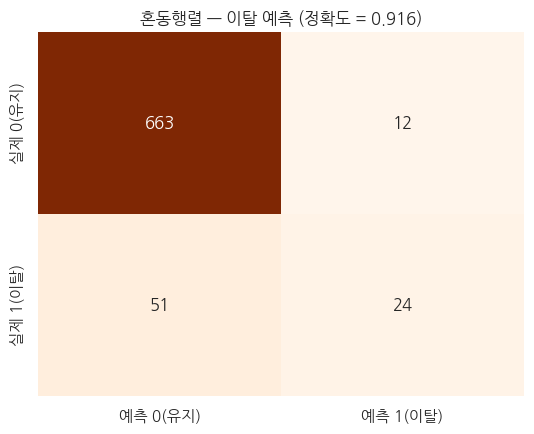

In [ ]:
# ─────────────────────────────────────────────
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로
# 불균형 데이터의 혼동행렬 — 놓침이 몇 명인지 (실행하면 격자와 놓침 인원이 출력됩니다)
# ─────────────────────────────────────────────
cm = confusion_matrix(y_te, pred)
tn_i, fp_i, fn_i, tp_i = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title(f"혼동행렬 — 이탈 예측 (정확도 = {accuracy_score(y_te, pred):.3f})")
plt.tight_layout()
plt.show()

churner = tp_i + fn_i
print(f"실제 이탈 고객 {churner}명 중")
print(f"  찾아낸 고객(TP)  = {tp_i}명")
print(f"  놓친 고객(FN)    = {fn_i}명  ← 전체 이탈자의 {fn_i / churner * 100:.0f}%")
print(f"헛경보(FP)         = {fp_i}명  (쿠폰 낭비)")
print()
print(f"→ 정확도 {accuracy_score(y_te, pred):.3f}이라는 숫자에 이 {fn_i}명이 숨어 있었습니다.")

> 👀 **[C10] 결과읽기**  
> 왼쪽 위 칸(TN=663)만 압도적으로 진합니다. 정확도의 분자를 이 칸이 거의 다 채우고 있다는 뜻입니다. 정작 우리가 관심 있는 오른쪽 아래 칸(TP=24)은 아주 옅고, 그 왼쪽의 놓침(FN=51)이 그보다 두 배 넘게 큽니다.

숫자로 정리하면 이렇습니다 — 실제 이탈 고객 **75명 중 51명(68%)을 놓쳤습니다.** 반대로 헛경보는 **12명**뿐입니다. 모델이 양성 예측을 보수적으로 내고 있습니다. 높은 점수를 받은 관측치만 "이탈"로 분류한 결과입니다.

그래서 정밀도는 **0.667** — 재현율(0.320)의 두 배가 넘습니다. 양성 예측 범위가 좁으면 정밀도가 재현율보다 높게 나타날 수 있습니다. 그러나 이 차이만으로 모델의 품질을 단정할 수 없으며 운영 목적과 함께 판단해야 합니다. 지목한 36명 중 24명은 맞혔지만, 실제 이탈 고객 75명 중 51명은 음성으로 분류했습니다.

> 💡 **핵심짚기**  
> 정확도는 전체 정답 비율을, 재현율은 실제 양성 중 찾아낸 비율을 보여줍니다. 불균형 데이터에서 소수 클래스 탐지가 중요하다면 **정확도만 보고하지 않고 혼동행렬·정밀도·재현율을 함께 확인합니다.**

## ⌨️ 백문이 불여일타! (3)

```
[문제]
1) 이탈률이 각각 30%, 10%, 1%, 0.1%인 데이터가 있다고 가정합니다.
   각 경우에 "무조건 다수로 찍기"의 정확도를 계산해 출력합니다.
2) 만약 어떤 팀이 "이탈 예측 모델 정확도 98%를 달성했다"고 보고했습니다.
   이 보고만으로 판단할 수 없는 이유를, 1번 결과를 근거로 한 줄 적습니다.
3) 그 팀에게 되물어야 할 질문 2개를 적습니다.
```

▶️ **코드 실행하기 · 코드 셀 11 [C11]**

In [ ]:
# [C11] Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 다수 클래스 비율이라는 숨은 출발선

churn_rates = [0.30, 0.10, 0.01, 0.001]

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# 1) 이탈률별 "무조건 다수로 찍기" 정확도
# ─────────────────────────────────────────────

for rate in churn_rates:
    naive_accuracy = 1 - rate
    print(f"이탈률 {rate*100:>5.1f}% → 무조건 유지로 찍기 정확도 = {naive_accuracy:.3f}")

print()

# ─────────────────────────────────────────────
# 2) "정확도 98%" 보고만으로 판단할 수 없는 이유
# ─────────────────────────────────────────────
print("2) 이탈률이 낮을수록(예: 1%, 0.1%) 아무 학습도 안 한 '다수로 찍기' 모델도")
print("   정확도 99.0%, 99.9%가 그냥 나온다. 따라서 '정확도 98%'만으로는")
print("   그 팀의 이탈률 자체가 몇 %인지 모르면, 모델이 실제로 뭔가 배웠는지")
print("   아니면 다수 클래스 비율을 그대로 반영한 것인지 구분할 수 없다.")

print()

# ─────────────────────────────────────────────
# 3) 되물어야 할 질문 2개
# ─────────────────────────────────────────────
print("3) Q1. 데이터의 실제 이탈률(support, 클래스 비율)이 몇 %인가요?")
print("      → 98%가 다수 클래스 비율보다 얼마나 높은지 봐야 의미를 알 수 있음")
print("   Q2. 재현율(또는 혼동행렬)은 얼마인가요?")
print("      → 실제 이탈자 중 몇 %를 잡아냈는지 봐야 '진짜 이탈 예측 성능'을 알 수 있음")

이탈률  30.0% → 무조건 유지로 찍기 정확도 = 0.700
이탈률  10.0% → 무조건 유지로 찍기 정확도 = 0.900
이탈률   1.0% → 무조건 유지로 찍기 정확도 = 0.990
이탈률   0.1% → 무조건 유지로 찍기 정확도 = 0.999

2) 이탈률이 낮을수록(예: 1%, 0.1%) 아무 학습도 안 한 '다수로 찍기' 모델도
   정확도 99.0%, 99.9%가 그냥 나온다. 따라서 '정확도 98%'만으로는
   그 팀의 이탈률 자체가 몇 %인지 모르면, 모델이 실제로 뭔가 배웠는지
   아니면 다수 클래스 비율을 그대로 반영한 것인지 구분할 수 없다.

3) Q1. 데이터의 실제 이탈률(support, 클래스 비율)이 몇 %인가요?
      → 98%가 다수 클래스 비율보다 얼마나 높은지 봐야 의미를 알 수 있음
   Q2. 재현율(또는 혼동행렬)은 얼마인가요?
      → 실제 이탈자 중 몇 %를 잡아냈는지 봐야 '진짜 이탈 예측 성능'을 알 수 있음


<details>
<summary>(클릭) 💡 힌트</summary>

- "무조건 다수로 찍기"의 정확도는 다수 클래스의 비율, 즉 `1 - 양성비율`입니다.
- `for rate in churn_rates:` 로 돌면서 `1 - rate`를 출력하면 됩니다.
- 2~3번은 코드가 아니라 주석이나 `print()`로 문장을 적으면 됩니다.

</details>

## 🚦 짚고 넘어가기

1. 불균형 데이터에서 정확도가 왜 높게 유지되는지 수식으로 설명할 수 있습니까?
2. 재현율 0.320이라는 값을 마케팅팀에게 **비즈니스 언어**로 한 문장으로 전달할 수 있습니까?
3. "다수 클래스 비율"을 반드시 함께 보고해야 하는 이유는 무엇입니까?

> ⏭️ **다음 학습 예고**  
> 정확도와 함께 정밀도·재현율을 확인했습니다. 그런데 이 둘은 **특정 임계값 하나에서의 성적**일 뿐입니다. 모델 전체의 실력을 하나의 숫자로 요약하려면 곡선이 필요합니다. 다음 Part에서 **ROC곡선과 PR곡선**을 만나는데, 놀랍게도 **같은 모델을 서로 다른 관점에서 요약**합니다.

# Part 4. ROC vs PR — 불균형에선 PR이 정직하다

지금까지 계산한 정밀도·재현율에는 숨은 전제가 하나 있었습니다. **임계값 0.5**입니다. 모델이 출력한 이탈 확률이 0.5를 넘으면 "이탈", 아니면 "유지"로 잘랐습니다.

그런데 0.5는 누가 정한 값일까요? 현재 사용하는 이진 분류기의 기본 판정값일 뿐, 비즈니스 비용을 반영해 정한 값은 아닙니다. 임계값을 바꾸면 정밀도와 재현율이 달라지므로 특정 운영점의 성적도 달라집니다. 모델이 출력한 점수와 순위 자체가 바뀌는 것은 아닙니다.

따라서 여러 임계값에서의 성능을 곡선으로 확인하고, 곡선을 요약한 지표로 모델의 순위 구분 능력을 평가합니다.

> ❓ **질문하기**  
> ROC와 PR은 같은 예측 점수를 어떤 관점에서 요약하며, 불균형 데이터에서는 무엇을 함께 확인해야 하는가?

## 💡 쉽게 말하면 — 같은 순위를 다른 관점에서 읽기

모델은 각 관측치에 양성일 가능성을 나타내는 점수를 부여합니다. ROC 곡선과 PR 곡선은 이 점수의 경계값을 바꾸며 성능을 살펴보지만, 강조하는 대상이 다릅니다.

**ROC 곡선**은 실제 양성과 실제 음성을 얼마나 잘 구분해 순위를 매기는지 봅니다. **PR 곡선**은 양성으로 지목한 대상의 정확성과 실제 양성을 찾아낸 비율에 집중합니다.

양성 클래스가 드물고 그 탐지가 중요한 문제에서는 PR 곡선이 소수 클래스의 운영 성능을 더 직접적으로 보여줍니다. ROC 곡선이 틀린 것은 아니며, 두 곡선은 서로 다른 질문에 답합니다.

![ROC 곡선 — 가로축이 거짓 양성률, 세로축이 참 양성률이며 왼쪽 위로 붙는 곡선이 좋은 모델이고 대각선 점선은 무작위 분류기를 뜻한다](https://upload.wikimedia.org/wikipedia/commons/3/36/Roc-draft-xkcd-style.svg)

_(출처: [Roc-draft-xkcd-style](https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg) — MartinThoma, CC0)_

> 🧭 **한눈에 보기**  
> 가로축은 **거짓 양성률**(음성을 양성이라 잘못 부른 비율), 세로축은 **참 양성률**(= 재현율)입니다. 왼쪽 위 모서리가 완벽한 분류기이고, 붉은 대각선은 **동전 던지기**입니다. 곡선이 왼쪽 위로 붙을수록(BETTER 화살표 방향) 좋고, 그 아래 면적이 **ROC-AUC**입니다.

## 🔍 자세히 알아보기 — 두 곡선의 분모가 다르다

두 곡선은 서로 다른 축으로 성능을 나타냅니다. 축과 기준선을 함께 확인해야 합니다.

|                      | ROC 곡선 | PR 곡선 |
| -------------------- | -------- | ------- |
| 가로축 | **거짓 양성률** $\dfrac{FP}{FP+TN}$ | **재현율** $\dfrac{TP}{TP+FN}$ |
| 세로축 | **참 양성률(재현율)** $\dfrac{TP}{TP+FN}$ | **정밀도** $\dfrac{TP}{TP+FP}$ |
| 요약 지표 | ROC-AUC | PR-AUC 또는 평균 정밀도(Average Precision, AP) |
| 무작위 기준 | 대각선, ROC-AUC의 기댓값 **0.5** | 정밀도의 기댓값이 **양성 비율 $\pi$** |

핵심은 **거짓 양성률의 분모**입니다.

$$\text{거짓 양성률} = \frac{FP}{FP + TN}$$

거짓 양성률은 실제 음성 집단 안에서의 비율이므로 클래스 비율의 영향을 직접 받지 않습니다. 반면 정밀도는 양성 예측 안에 실제 양성이 얼마나 포함됐는지를 계산하므로 **양성 비율에 민감합니다.** 같은 순위 성능을 가진 모델도 양성이 드물어지면 정밀도가 낮아질 수 있습니다.

### 기준선이 다르다는 점이 결정적이다

점수가 양성과 음성을 무작위로 순위화한다면 ROC-AUC의 기댓값은 **0.5**입니다. 그래서 "ROC-AUC 0.76"이라고 하면 0.5 대비 꽤 좋아 보입니다.

무작위 점수에서 기대되는 정밀도는 **양성 비율 $\pi$** 입니다. 양성이 10%면 기준선이 **0.10**이고, 1%면 **0.01**입니다. 따라서 PR 곡선의 요약값은 양성 비율과 함께 읽어야 합니다.

> ⚠️ **주의하기**  
> PR 곡선의 요약값 0.5를 그 자체로 “보통”이라고 판단할 수 없습니다. 양성 비율이 0.1이라면 무작위 기준보다 높지만, 실제 채택 여부는 운영점의 정밀도·재현율과 비용을 함께 확인해 결정합니다.

> 🔗 **개념 연결하기**  
> 이것은 지난 시간의 베이스라인 이야기와 정확히 같은 구조입니다. 점수 하나만으로는 좋은지 알 수 없고, **그 문제의 기준선을 알아야** 판단할 수 있습니다. 정확도의 기준선으로 다수 클래스 비율을 확인했듯, PR 곡선은 양성 비율을 기준으로 함께 해석합니다.

> 📌 **실무 연결하기**  
> 불균형 문제에서 ROC-AUC만 제시하면 특정 운영점에서 소수 클래스를 얼마나 찾는지 알 수 없습니다. **금융** 사기 탐지나 **헬스케어** 희귀질환 모델의 보고서를 읽을 때는 PR 곡선의 요약값과 함께 정밀도·재현율·선택한 임계값이 제시됐는지 확인합니다.

## 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선

같은 모델(같은 확률 출력)로 두 곡선을 나란히 그립니다. 곡선이 다르게 생겼을 뿐 아니라, **요약 점수의 값도 다르게 나타납니다.**

> 🤔 **예상하기**  
> [C9]의 로지스틱 회귀는 재현율 0.320으로 이탈자의 68%를 놓쳤습니다. 이 모델의 **ROC-AUC**는 얼마쯤 나올 것 같습니까? 0.6 근처일까요, 0.9 근처일까요? 그리고 **AP**는 양성 비율 0.100보다 얼마나 높을까요?

▶️ **코드 실행하기 · 코드 셀 12 [C12]**

ROC-AUC = 0.899   (무작위 기준선 0.500 → 기준선의 1.8배)
AP      = 0.539   (양성 비율 0.100)


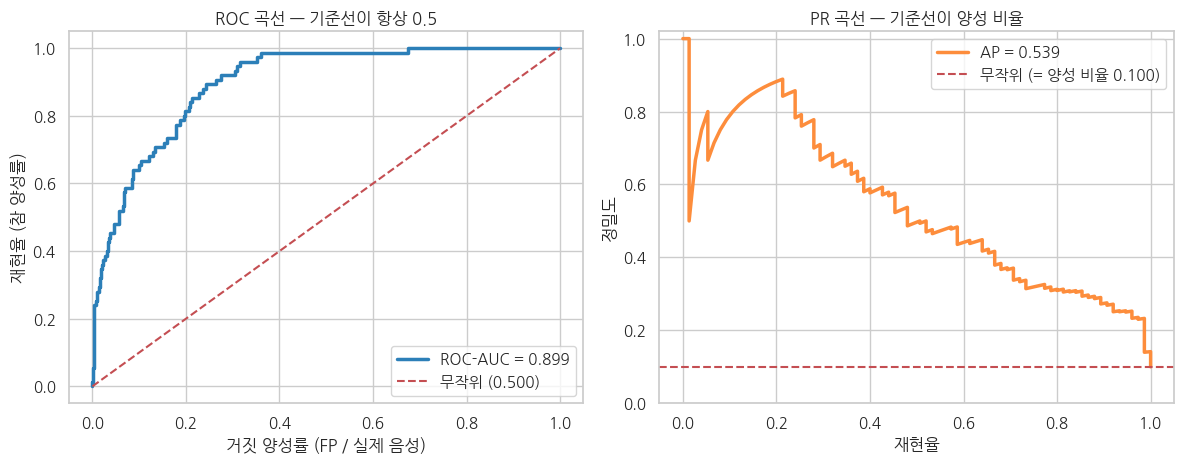

In [ ]:
# ─────────────────────────────────────────────
# [C12] Part 4 · 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선
# ROC곡선과 PR곡선을 나란히 (실행하면 두 곡선과 각각의 면적 점수가 나옵니다)
# ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)

roc_auc = roc_auc_score(y_te, proba)
ap = average_precision_score(y_te, proba)
baseline = y_te.mean()          # PR곡선의 무작위 기준선 = 양성 비율

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(fpr, tpr, lw=2.5, color="#2c7fb8", label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "r--", lw=1.5, label="무작위 (0.500)")
axes[0].set_xlabel("거짓 양성률 (FP / 실제 음성)")
axes[0].set_ylabel("재현율 (참 양성률)")
axes[0].set_title("ROC 곡선 — 기준선이 항상 0.5")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, lw=2.5, color="#fd8d3c", label=f"AP = {ap:.3f}")
axes[1].axhline(baseline, color="r", ls="--", lw=1.5,
                label=f"무작위 (= 양성 비율 {baseline:.3f})")
axes[1].set_xlabel("재현율")
axes[1].set_ylabel("정밀도")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("PR 곡선 — 기준선이 양성 비율")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"ROC-AUC = {roc_auc:.3f}   (무작위 기준선 0.500 → 기준선의 {roc_auc / 0.5:.1f}배)")
print(f"AP      = {ap:.3f}   (양성 비율 {baseline:.3f})")

> 🎯 **[C12] 확인하기**  
> ROC-AUC는 **0.899**입니다. 이 값은 모델이 임의의 양성 표본에 임의의 음성 표본보다 높은 점수를 부여할 가능성이 크다는 뜻입니다. 반면 임계값 0.5에서의 재현율은 0.320입니다. **순위 구분 능력이 좋아도 기본 운영점이 적절하다는 뜻은 아닙니다.**

[C12]에서 `average_precision_score`로 계산한 평균 정밀도(AP)는 **0.539**이고, 양성 비율 0.100보다 높습니다. AP와 ROC-AUC는 축과 계산 방식이 다르므로 값의 크기나 기준선 대비 배수를 서로 직접 비교하지 않습니다.

> ⚠️ **주의하기 — AP와 PR-AUC**  
> 이 노트북의 코드는 scikit-learn의 평균 정밀도(AP)를 사용합니다. AP는 재현율 증가분으로 정밀도를 가중해 PR 곡선을 요약합니다. 사다리꼴 적분으로 구한 PR-AUC와 유사한 목적을 갖지만 계산값이 항상 같지는 않습니다. 이후 코드와 설명에서는 실제 계산값을 **AP**로 표기합니다.

이제 양성 비율이 달라질 때 ROC-AUC와 AP가 어떻게 반응하는지 비교합니다.

▶️ **코드 실행하기 · 코드 셀 13 [C13]**

In [ ]:
# ─────────────────────────────────────────────
# [C13] Part 4 · 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선
# 이탈 비율을 30% → 2.7%로 낮추며 두 점수의 반응 비교 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
# 절편(churn_base)만 바꿔 이탈 비율을 만듭니다. 피처 생성 규칙은 그대로입니다
BASE_BY_RATE = {0.30: 0.911, 0.10: -1.188, 0.05: -2.278, 0.027: -2.994}

records = []
for target, base in BASE_BY_RATE.items():
    d = make_moduplay(churn_base=base)
    Xa, ya = d[FEATURES], d["churn"]
    a_tr, a_te, ya_tr, ya_te = train_test_split(
        Xa, ya, test_size=0.25, random_state=RANDOM_STATE, stratify=ya)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(a_tr, ya_tr)
    pa = m.predict_proba(a_te)[:, 1]
    records.append({
        "이탈 비율": f"{ya.mean():.1%}",
        "ROC-AUC": roc_auc_score(ya_te, pa),
        "AP": average_precision_score(ya_te, pa),
        "PR 기준선": ya_te.mean(),
    })

sweep = pd.DataFrame(records)
print(sweep.round(3).to_string(index=False))
print()
print("→ 이탈 비율이 30%에서 2.7%로 떨어지는 동안")
print(f"   ROC-AUC는 {sweep['ROC-AUC'].iloc[0]:.3f} → {sweep['ROC-AUC'].iloc[-1]:.3f}")
print(f"   AP는       {sweep['AP'].iloc[0]:.3f} → {sweep['AP'].iloc[-1]:.3f} (크게 하락)")

이탈 비율  ROC-AUC    AP  PR 기준선
30.0%    0.869 0.746   0.300
10.0%    0.899 0.539   0.100
 5.0%    0.895 0.345   0.049
 2.7%    0.810 0.155   0.027

→ 이탈 비율이 30%에서 2.7%로 떨어지는 동안
   ROC-AUC는 0.869 → 0.810
   AP는       0.746 → 0.155 (크게 하락)


> 👀 **[C13] 결과읽기**  
> 이 표는 이 합성 실험에서 양성 비율 변화에 따라 두 요약값이 어떻게 달라지는지 보여줍니다. 이탈 비율이 **30% → 2.7%** 로 떨어지는 동안,

- **ROC-AUC: 0.869 → 0.810** — 비교적 작은 폭으로 변합니다. ROC-AUC는 양성과 음성의 순위 구분을 클래스 내부 비율로 평가하므로 양성 비율 변화에 직접 좌우되지 않습니다.
- **AP: 0.746 → 0.155** — 큰 폭으로 낮아집니다. 정밀도는 양성 비율의 영향을 받으므로, 양성이 드물어질수록 같은 수의 거짓 양성도 더 크게 반영됩니다.

이 결과는 불균형 문제에서 PR 관점이 소수 클래스의 양성 예측 품질을 더 직접적으로 보여줄 수 있음을 설명합니다. 다만 두 지표 중 하나를 보편적으로 폐기하지 않고, **ROC-AUC·AP·운영점 지표를 목적에 맞게 함께 제시합니다.**

> 💡 **핵심짚기**  
> 실무 보고에서는 ROC-AUC와 AP를 구분해 제시하고 **양성 비율**을 함께 적습니다. 최종 의사결정에는 선택한 임계값의 정밀도·재현율과 오류 비용을 사용합니다. 임계값 전체를 요약한 값만으로 배포 여부를 결정하지 않습니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
1) [C12]에서 만든 proba로, 재현율이 0.6 이상이 되는 지점들 중
   정밀도가 가장 높은 지점의 (정밀도, 재현율)을 찾아 출력합니다.
   힌트: `precision_recall_curve`가 반환한 `prec`, `rec` 배열을 사용합니다.
2) 그 지점의 정밀도를 보고, "재현율 0.6을 확보하려면 무엇을 지불해야 하는가"를
   한 줄로 적습니다.
3) 무작위 모델의 기대 정밀도가 왜 양성 비율과 같아지는지 한 줄로 설명합니다.
```

▶️ **코드 실행하기 · 코드 셀 14 [C14]**

In [ ]:
# [C14] Part 4 · ⌨️ 백문이 불여일타! (4)
# ⌨️ 백문이 불여일타! (4) — 재현율 0.6을 확보하는 대가는 얼마인가

# (prec, rec 는 [C12]에서 precision_recall_curve로 만들어 둔 그대로입니다)

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# 1) 재현율 >= 0.6인 지점들 중 정밀도가 가장 높은 지점 찾기
# ─────────────────────────────────────────────
mask = rec >= 0.6                     # 재현율 0.6 이상인 지점만 True
prec_filtered = prec[mask]
rec_filtered = rec[mask]

best_idx = np.argmax(prec_filtered)   # 걸러낸 것 중 정밀도가 가장 높은 위치
best_precision = prec_filtered[best_idx]
best_recall = rec_filtered[best_idx]

print(f"재현율 ≥ 0.6 지점 중 정밀도가 가장 높은 곳:")
print(f"  정밀도 = {best_precision:.3f}, 재현율 = {best_recall:.3f}")

# 2) "재현율 0.6을 확보하려면 무엇을 지불해야 하는가"

# 재현율 0.6(이탈자 10명 중 6명을 잡음)을 얻으려면, 정밀도가 0.449까지 떨어진다 — 즉 "이탈"이라고 예측한 사람 중 약 55%는 실제로는 이탈하지 않을 사람이라, 그만큼 쿠폰/캠페인이 헛되이 뿌려진다.

# 3) 무작위 모델의 기대 정밀도가 왜 양성 비율과 같아지나요?

# 무작위 모델은 아무 정보도 없이 사람들을 "이탈"이라고 찍기 때문에, 그렇게 찍힌 사람들의 구성은 전체 데이터의 구성 비율과 같아진다 — 즉 그중 실제 이탈자 비율은 데이터 전체의 양성 비율(baseline)과 같아진다.

재현율 ≥ 0.6 지점 중 정밀도가 가장 높은 곳:
  정밀도 = 0.449, 재현율 = 0.640


<details>
<summary>(클릭) 💡 힌트</summary>

- `rec >= 0.6` 은 불리언 배열을 만듭니다. 이것으로 `prec`을 걸러낼 수 있습니다.
- 걸러낸 정밀도 중 최댓값의 위치는 `np.argmax()`로 찾을 수 있습니다. 마스크를 쓴 인덱싱과 원본 인덱스가 어긋나지 않도록 주의합니다.
- 3번은 코드가 아니라 문장입니다. 무작위 모델이 "아무나 양성이라 찍었을 때" 그중 실제 양성의 비율이 얼마일지 생각합니다.

</details>

## 🚦 짚고 넘어가기

1. 거짓 양성률과 정밀도의 **분모** 차이를 설명할 수 있습니까?
2. AP 0.35를 보고 좋은지 나쁜지 판단하려면 무엇을 더 알아야 합니까?
3. 불균형 데이터 보고서에서 ROC-AUC만 제시하는 것이 왜 문제입니까?

> ⏭️ **다음 학습 예고**  
> 지금까지 우리는 모델을 **관찰**했습니다. 마지막 Part에서는 드디어 **손잡이를 잡습니다.** 확률을 예/아니오로 자르는 기준인 **임계값**, 그리고 학습 단계에서 소수 클래스에 무게를 더 주는 **`class_weight`** 입니다. 운영점은 모델 점수뿐 아니라 **오류 비용과 처리 용량**을 반영해 정한다는 점을 숫자로 확인합니다.

# Part 5. 임계값과 `class_weight` — 운영점을 고른다

모델의 `predict()`는 우리에게 예/아니오를 줍니다. 그런데 그 뒤에서 실제로 일어나는 일은 이렇습니다.

```
확률 0.73  →  0.5 넘음  →  "이탈"
확률 0.31  →  0.5 못 넘음  →  "유지"
```

**0.5는 모델이 학습한 값이 아닙니다.** 현재 사용하는 이진 로지스틱 회귀에서 사용하는 기본 판정값입니다. 그리고 이 값을 바꾸는 것만으로 모델의 정밀도·재현율은 완전히 달라집니다. 재학습도, 새 데이터도 필요 없습니다.

> ❓ **질문하기**  
> 임계값을 어디에 두어야 하고, 그 근거는 무엇으로 대는가?

## 💡 쉽게 말하면 — 경보기의 민감도 손잡이

화재 경보기에 민감도 손잡이가 있다고 가정합니다.

**민감하게 돌리면** — 작은 연기에도 울립니다. 진짜 화재를 놓치지 않습니다(재현율↑). 대신 요리할 때마다 울립니다(정밀도↓).

**둔감하게 돌리면** — 확실할 때만 울립니다. 헛경보가 거의 없습니다(정밀도↑). 대신 초기 화재를 놓칠 수 있습니다(재현율↓).

**여기에 옳은 위치는 없습니다.** 서버실이라면 민감하게, 주방이라면 둔감하게 돌리는 것이 맞습니다. 손잡이의 위치는 **그 공간에서 어떤 실수가 더 비싼가**로 정합니다.

임계값이 바로 이 손잡이입니다. 그리고 오늘 배울 두 번째 손잡이 `class_weight`는 조금 다릅니다 — 이것은 **학습 단계에서** 소수 클래스의 실수에 더 큰 벌점을 매기는 방식입니다.

|             | 임계값                      | `class_weight`                |
| ----------- | --------------------------- | ----------------------------- |
| 언제 작동   | 학습 **후**, 예측을 자를 때 | 학습 **중**, 손실을 계산할 때 |
| 재학습 필요 | 없음 (확률만 다시 자름)     | 있음                          |
| 바꾸는 것   | 운영점 하나                 | 모델 자체                     |

## 🔍 자세히 알아보기 — 두 손잡이의 작동 원리

### 임계값 — 확률을 자르는 위치

모델의 예측은 이렇게 만들어집니다.

$$\hat{y} = \begin{cases} 1 & \text{if } P(y=1 \mid x) \geq t \\ 0 & \text{otherwise} \end{cases}$$

- $P(y=1 \mid x)$ — 모델이 출력한 양성 확률 (`predict_proba`의 두 번째 열. 이 값이 실제 확률로 잘 보정됐는지는 별도로 검증해야 함)
- $t$ — 임계값. 현재 이진 분류 모델의 `predict()`는 $t = 0.5$를 사용

$t$를 **낮추면** 양성 예측이 늘어납니다. 그러면 TP도 늘고 FP도 늡니다 → 재현율은 높아지고 정밀도는 낮아지는 경향이 나타납니다. $t$를 **높이면** 반대입니다.

$t$를 바꿔도 **학습된 모델은 바뀌지 않습니다.** 확률 순서는 그대로이고, 자르는 위치만 옮기는 것입니다. 그래서 ROC-AUC·AP 같은 임계값 독립 요약 지표는 **임계값과 무관하게 일정합니다.** 곡선 위의 한 점을 고르는 일이 임계값 결정입니다.

### 비용으로 정하는 법 — 근거를 숫자로

임계값을 "감"으로 정하면 설득할 수 없습니다. 비용을 넣으면 계산이 됩니다.

$$\text{총비용}(t) = FN(t) \times C_{FN} + FP(t) \times C_{FP}$$

- $C_{FN}$ — 놓침 1건의 비용 (예: 이탈로 잃는 고객 생애가치)
- $C_{FP}$ — 헛경보 1건의 비용 (예: 불필요한 쿠폰 단가)

여러 $t$에 대해 이 값을 계산해 **총비용이 가장 낮은 $t$** 를 후보로 선택합니다. 그러면 “임계값을 0.25로 정했습니다”에서 그치지 않고 **"임계값 0.25에서 예상 손실이 최소(406만원)이므로 이 값을 택했습니다"** 라고 보고할 수 있습니다.

### `class_weight` — 학습 단계의 무게추

`class_weight="balanced"`를 주면 모델은 각 클래스의 가중치를 이렇게 잡습니다.

$$w_c = \frac{n}{k \cdot n_c}$$

- $n$ — 전체 표본 수, $k$ — 클래스 수, $n_c$ — 클래스 $c$의 표본 수
- 즉 **드문 클래스에 큰 가중치**가 붙습니다

양성이 10%라면 이 공식에서 양성 가중치는 음성 가중치의 약 9배입니다. 손실 함수에서 양성 표본의 오분류가 더 크게 반영되므로 모델은 양성을 더 많이 예측할 수 있습니다.

> ⚠️ **주의하기 — 확률 보정과 가중치**  
> 비용에서 이론적으로 임계값을 직접 계산하려면 예측 확률의 보정(Calibration) 상태도 확인해야 합니다. 보정이 좋지 않으면 `CalibratedClassifierCV` 같은 방법을 검토합니다. 이 노트북처럼 검증 데이터에서 후보 임계값별 실제 비용을 직접 비교하는 방법도 사용할 수 있습니다.
>
> `class_weight`가 항상 성능을 개선하는 것은 아닙니다. 재현율이 올라가는 경우에도 정밀도나 다른 지표는 낮아질 수 있으므로 검증 데이터에서 비교해야 합니다. 그리고 잠시 뒤 [C18]에서 더 놀라운 것을 보게 됩니다 — **이 실험에서는 AP가 거의 변하지 않는다**는 사실입니다. 이 결과가 무엇을 의미하고 무엇을 의미하지 않는지 구분합니다.

> 📌 **실무 연결하기**  
> 임계값 조정은 **금융**에서 사기 심사 인력 규모에 맞춰 정하고(심사 가능 건수는 양성 예측 수의 제약), **헬스케어**에서 재검사 수용량에 맞춰 정하며, **제조**에서 재검사 라인 처리량에 맞춰 정합니다. 비용뿐 아니라 **운영 가능한 처리량**도 임계값의 제약 조건이 됩니다.

## 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기

먼저 임계값을 훑으며 세 지표가 어떻게 움직이는지 표로 봅니다.

> 🤔 **예상하기**  
> 임계값 0.5에서 재현율은 0.320, 정밀도는 0.667이었습니다. 임계값을 0.3으로 낮추면 두 값은 어떻게 될까요? 그리고 **F1은 올라갈까요, 내려갈까요?** 정밀도가 떨어지는데도 F1이 올라갈 수 있을까요?

▶️ **코드 실행하기 · 코드 셀 15 [C15]**

In [ ]:
# ─────────────────────────────────────────────
# [C15] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 임계값을 훑으며 지표 변화 추적 (실행하면 임계값별 지표·놓침·헛경보 표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    p_t = (proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
    rows.append({
        "임계값": t,
        "정확도": accuracy_score(y_te, p_t),
        "정밀도": precision_score(y_te, p_t, zero_division=0),
        "재현율": recall_score(y_te, p_t),
        "F1": f1_score(y_te, p_t, zero_division=0),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
    })
sweep_t = pd.DataFrame(rows)
print(sweep_t.round(3).to_string(index=False))
print()
best = sweep_t.loc[sweep_t["F1"].idxmax()]
print(f"→ F1이 가장 높은 임계값은 {best['임계값']:.1f} (F1 = {best['F1']:.3f})")
print(f"  기본값 0.5의 F1은 {sweep_t['F1'].iloc[0]:.3f}이었습니다 — 기본값은 최적이 아닙니다.")

 임계값   정확도   정밀도   재현율    F1  놓침(FN)  헛경보(FP)
 0.5 0.916 0.667 0.320 0.432      51       12
 0.4 0.916 0.636 0.373 0.471      47       16
 0.3 0.905 0.529 0.480 0.503      39       32
 0.2 0.855 0.375 0.680 0.483      24       85
 0.1 0.780 0.294 0.853 0.437      11      154

→ F1이 가장 높은 임계값은 0.3 (F1 = 0.503)
  기본값 0.5의 F1은 0.432이었습니다 — 기본값은 최적이 아닙니다.


> 🎯 **[C15] 확인하기**  
> 임계값 0.5 → 0.3으로 낮추자,

- 재현율 **0.320 → 0.480** (놓침 51명 → 39명)
- 정밀도 **0.667 → 0.529** (헛경보 12명 → 32명)
- **F1 0.432 → 0.503** — 정밀도가 떨어졌는데도 **올라갔습니다**

정밀도를 잃었지만 재현율을 더 많이 얻었기 때문입니다. 조화평균은 낮은 쪽에 끌려가므로, **가장 낮은 값을 끌어올리는 것이 F1에 가장 큰 이득**이 됩니다.

그리고 결정적인 사실 하나 — **기본값 0.5의 F1(0.432)은 최적이 아니었습니다.** 기본값은 이 데이터의 F1이나 비용을 기준으로 선택된 값이 아니기 때문입니다. 임계값을 0.2로 더 내리면 재현율은 0.680까지 오르지만 F1은 0.483으로 다시 떨어집니다 — 정밀도 손실이 이득을 넘어서는 지점입니다.

이 관계를 곡선으로 보면 트레이드오프가 한눈에 들어옵니다.

▶️ **코드 실행하기 · 코드 셀 16 [C16]**

F1이 가장 높은 임계값 = 0.27 (F1 = 0.524)  ← 기본값 0.5보다 왼쪽입니다
→ 정밀도와 재현율이 정확히 반대로 움직입니다. 둘을 동시에 올리는 임계값은 없습니다.


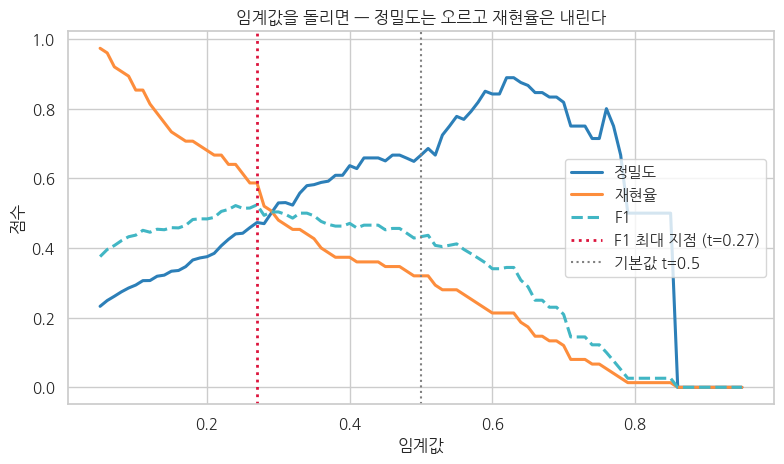

In [ ]:
# ─────────────────────────────────────────────
# [C16] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 임계값에 따른 정밀도·재현율·F1 (실행하면 세 곡선이 한 그림에 그려집니다)
# ─────────────────────────────────────────────
ts = np.linspace(0.05, 0.95, 91)
p_list, r_list, f_list = [], [], []
for t in ts:
    p_t = (proba >= t).astype(int)
    p_list.append(precision_score(y_te, p_t, zero_division=0))
    r_list.append(recall_score(y_te, p_t))
    f_list.append(f1_score(y_te, p_t, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(ts, p_list, lw=2.2, label="정밀도", color="#2c7fb8")
ax.plot(ts, r_list, lw=2.2, label="재현율", color="#fd8d3c")
ax.plot(ts, f_list, lw=2.2, label="F1", color="#41b6c4", ls="--")
best_t = ts[int(np.argmax(f_list))]
ax.axvline(best_t, color="crimson", ls=":", lw=2,
           label=f"F1 최대 지점 (t={best_t:.2f})")
ax.axvline(0.5, color="gray", ls=":", lw=1.5, label="기본값 t=0.5")
ax.set_xlabel("임계값")
ax.set_ylabel("점수")
ax.set_title("임계값을 돌리면 — 정밀도는 오르고 재현율은 내린다")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"F1이 가장 높은 임계값 = {best_t:.2f} (F1 = {max(f_list):.3f})  ← 기본값 0.5보다 왼쪽입니다")
print("→ 정밀도와 재현율이 정확히 반대로 움직입니다. 둘을 동시에 올리는 임계값은 없습니다.")

> 👀 **[C16] 결과읽기**  
> 이 데이터에서는 임계값이 높아질수록 정밀도는 대체로 오르고 재현율은 내려갑니다. 유한한 데이터에서는 정밀도가 구간별로 흔들릴 수 있으므로 항상 단조 증가한다고 단정하지 않습니다. 점선 F1의 최댓값은 정밀도와 재현율을 같은 비중으로 요약했을 때의 후보 운영점입니다.

회색 점선(기본값 0.5)이 붉은 점선(F1 최대)보다 **오른쪽에 있음**을 확인합니다. 기본값은 이 문제에서 **필요 이상으로 보수적**이었습니다.

그런데 F1 최대점이 정말 우리가 원하는 지점일까요? F1은 정밀도와 재현율을 **동등하게** 취급합니다. 하지만 모두플레이에서 고객을 잃는 손실과 쿠폰 한 장의 비용이 같을 리 없습니다. **비용을 넣어 다시 계산해야 합니다.**

▶️ **코드 실행하기 · 코드 셀 17 [C17]**

In [ ]:
# ─────────────────────────────────────────────
# [C17] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 비용으로 임계값 정하기 (실행하면 임계값별 총비용과 최소 지점이 나옵니다)
# ─────────────────────────────────────────────
# 모두플레이 마케팅팀이 알려준 숫자
COST_FN = 10   # 놓침 1건 = 이탈로 잃는 고객 생애가치 10만원
COST_FP = 2    # 헛경보 1건 = 불필요한 방어 쿠폰 2만원

rows = []
for t in np.arange(0.05, 0.85, 0.05):
    p_t = (proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
    rows.append({
        "임계값": round(t, 2),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
        "총비용(만원)": fn_t * COST_FN + fp_t * COST_FP,
    })
cost = pd.DataFrame(rows)
print(f"놓침 1건 = {COST_FN}만원 / 헛경보 1건 = {COST_FP}만원 (비용비 {COST_FN // COST_FP}:1)")
print()
print(cost[cost["임계값"] <= 0.55].to_string(index=False))

opt = cost.loc[cost["총비용(만원)"].idxmin()]
print()
print(f"→ 총비용이 최소인 임계값 = {opt['임계값']:.2f}  (총비용 {int(opt['총비용(만원)'])}만원)")
print(f"  기본값 0.5의 총비용은 {int(cost.loc[cost['임계값'] == 0.5, '총비용(만원)'].iloc[0])}만원이었습니다.")

놓침 1건 = 10만원 / 헛경보 1건 = 2만원 (비용비 5:1)

 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241      502
0.10      11      154      418
0.15      20      110      420
0.20      24       85      410
0.25      29       58      406
0.30      39       32      454
0.35      43       23      476
0.40      47       16      502
0.45      49       14      518
0.50      51       12      534
0.55      54        6      552

→ 총비용이 최소인 임계값 = 0.25  (총비용 406만원)
  기본값 0.5의 총비용은 534만원이었습니다.


> 👀 **[C17] 결과읽기**  
> 이 예제의 비용 가정에서는 총비용이 **U자 형태**로 나타납니다. 임계값이 너무 낮으면 헛경보가 폭발하고(t=0.05에서 502만원), 너무 높으면 놓침이 쌓입니다(t=0.5에서 534만원). 그 사이 **t=0.25에서 406만원**으로 최소가 됩니다.

이제 보고할 문장이 완전히 달라집니다.

> "임계값을 0.25로 설정했습니다. 놓침 1건을 10만원, 헛경보 1건을 2만원으로 놓고 계산했을 때 예상 손실이 406만원으로 최소이며, 기본값 0.5(534만원)보다 **128만원 낮습니다.**"

**임계값과 함께 비용 가정을 기록해야 결과를 재검토할 수 있습니다.** 숫자와 가정이 함께 있으므로, 나중에 쿠폰 단가가 바뀌면 계산을 다시 해서 임계값을 갱신할 수 있습니다.

> 💡 **핵심짚기**  
> 이 데이터와 탐색 범위에서는 비용비($C_{FN} : C_{FP}$)가 클수록 비용 최소 임계값이 낮아집니다. 놓침이 아플수록 그물을 크게 던지는 것이 맞기 때문입니다. 따라서 임계값은 모델 성능뿐 아니라 비즈니스 비용을 반영해 결정합니다.

이제 두 번째 손잡이인 `class_weight`를 확인합니다. 지난 시간 배운 계층 교차 검증으로 전후를 비교합니다.

> ⚠️ **주의하기 — 검증 데이터에서 선택하기**  
> 이 노트북에서는 개념을 비교하기 위해 테스트 데이터에서 비용 곡선을 그렸습니다. 실제 업무에서는 검증 데이터 또는 교차 검증의 OOF(Out-of-Fold) 예측으로 임계값을 정하고, 테스트 데이터는 최종 평가에 한 번만 사용합니다. 또한 이 비용식은 TP의 쿠폰 비용과 유지 효과를 이미 순편익에 반영했다고 가정한 단순 모형입니다.

▶️ **코드 실행하기 · 코드 셀 18 [C18]**

In [ ]:
# ─────────────────────────────────────────────
# [C18] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# class_weight 보정 전후 — 계층 5겹 교차 검증 (실행하면 네 지표의 전후 비교표가 나옵니다)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for cw, label in [(None, "보정 없음"), ("balanced", "class_weight='balanced'")]:
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight=cw, random_state=RANDOM_STATE),
    )
    rows.append({
        "설정": label,
        "재현율": cross_val_score(pipe, X, y, cv=cv, scoring="recall").mean(),
        "정밀도": cross_val_score(pipe, X, y, cv=cv, scoring="precision").mean(),
        "F1": cross_val_score(pipe, X, y, cv=cv, scoring="f1").mean(),
        "AP": cross_val_score(pipe, X, y, cv=cv, scoring="average_precision").mean(),
    })
cw_compare = pd.DataFrame(rows)
print("계층 5겹 교차 검증 평균")
print(cw_compare.round(3).to_string(index=False))
print()
d_recall = cw_compare["재현율"].iloc[1] - cw_compare["재현율"].iloc[0]
d_prec = cw_compare["정밀도"].iloc[1] - cw_compare["정밀도"].iloc[0]
d_ap = cw_compare["AP"].iloc[1] - cw_compare["AP"].iloc[0]
print(f"→ 재현율 변화: {d_recall:+.3f}   (약 {cw_compare['재현율'].iloc[1] / cw_compare['재현율'].iloc[0]:.1f}배)")
print(f"  정밀도 변화: {d_prec:+.3f}   ← 재현율을 산 값입니다")
print(f"  AP 변화: {d_ap:+.3f}   ← 순위 요약 성능의 변화를 함께 확인합니다")

계층 5겹 교차 검증 평균
                     설정  재현율   정밀도    F1    AP
                  보정 없음 0.29 0.672 0.405 0.532
class_weight='balanced' 0.81 0.297 0.434 0.534

→ 재현율 변화: +0.520   (약 2.8배)
  정밀도 변화: -0.375   ← 재현율을 산 값입니다
  AP 변화: +0.002   ← 순위 요약 성능의 변화를 함께 확인합니다


> 👀 **[C18] 결과읽기**  
> `class_weight="balanced"`를 주었을 때 지표별 변화 방향과 크기가 서로 다릅니다.

| 지표   | 보정 없음 | balanced  | 변화                     |
| ------ | --------- | --------- | ------------------------ |
| 재현율 | 0.290     | **0.810** | **+0.520 (약 2.8배)**    |
| 정밀도 | 0.672     | **0.297** | **−0.375 (반토막 이하)** |
| F1     | 0.405     | 0.434     | +0.030                   |
| AP | 0.532     | 0.534     | **+0.002 (거의 불변)**   |

**가장 중요한 줄은 맨 아래입니다.** AP가 0.532에서 0.534로 **거의 변하지 않았습니다.**

AP는 여러 재현율 수준에서 정밀도를 요약하며 예측 순위의 품질을 반영합니다. 이 실험에서 AP가 거의 같다는 것은 **두 설정의 순위 요약 성능이 비슷했다**는 뜻입니다. 그러나 `class_weight`는 학습 손실을 바꾸므로 계수와 예측 순위도 달라질 수 있습니다. 임계값만 옮긴 것과 동일하다고 단정할 수 없습니다.

여기서 두 가지를 배웁니다.

첫째, **`class_weight`는 모든 지표를 함께 올리는 스위치가 아닙니다.** 이 실험에서는 재현율이 오르고 정밀도가 낮아졌습니다. 채택 여부는 검증 지표와 오류 비용을 함께 보고 판단합니다.

둘째, **어떤 지표를 우선하느냐에 따라 채택 판단이 달라집니다.**

- 재현율을 우선하면 `balanced` 설정이 유리합니다(0.290 → 0.810).
- 정밀도를 우선하면 보정하지 않은 설정이 유리합니다(0.672 → 0.297).
- F1 차이는 +0.030이며, 변동성을 함께 확인해야 합니다.
- AP 차이는 +0.002로 두 설정의 순위 요약 성능이 비슷합니다.

같은 결과도 우선하는 지표에 따라 판단이 달라집니다. **운영 목적과 오류 비용이 판단 기준이 됩니다.** 모두플레이처럼 놓침(고객 상실)이 헛경보(쿠폰)보다 5배 비싸다면 재현율 쪽 결론이 맞습니다. 반대로 쿠폰 예산이 빡빡하다면 정밀도 쪽이 맞습니다.

> 💡 **핵심짚기**  
> 그리고 하나 더 확인합니다. 이 실험에서는 기본 모델의 임계값을 낮추어 `class_weight` 모델과 비슷한 재현율을 얻을 수 있습니다. 그러나 두 방법이 항상 같은 예측을 만드는 것은 아닙니다. 검증 데이터에서 비용·용량·AP를 비교하고, 더 단순한 대안이 요구 조건을 충족하면 임계값 조정을 우선 후보로 둘 수 있습니다.

> 💡 **핵심짚기**  
> _"지표를 고르는 것은 계산이 아니라 결정이다."_ 오늘 배운 모든 지표는 같은 네 칸에서 나온 나눗셈일 뿐입니다. 어느 나눗셈을 볼지 고르는 순간 여러분은 **"어떤 실수를 감수하겠다"는 비즈니스 판단**을 내리는 것입니다. 지표가 결정을 대신하지 않도록 선택 근거를 기록합니다.

## ⌨️ 백문이 불여일타! (5)

```
[문제]
1) [C17]의 비용 계산을 쿠폰 단가가 오른 상황으로 다시 계산합니다.
   COST_FN = 10 (그대로), COST_FP = 5 (2만원 → 5만원)
   총비용이 최소가 되는 임계값이 어디로 옮겨갑니까?
2) 반대로 고객 생애가치가 30만원으로 재평가됐다면(COST_FN = 30, COST_FP = 2)
   최적 임계값은 어디로 옮겨갑니까?
3) 1번과 2번의 결과를 보고, "비용비와 최적 임계값의 관계"를 한 줄로 정리합니다.
```

▶️ **코드 실행하기 · 코드 셀 19 [C19]**

In [ ]:
# [C19] Part 5 · ⌨️ 백문이 불여일타! (5)
# ⌨️ 백문이 불여일타! (5) — 비용이 바뀌면 최적 임계값은 어디로 가는가

scenarios = [(10, 2, "기준 (5:1)"), (10, 5, "쿠폰 인상 (2:1)"), (30, 2, "생애가치 상향 (15:1)")]

# 여기에 코드를 작성하세요

def find_optimal_threshold(cost_fn, cost_fp, proba, y_te):
    rows = []
    for t in np.arange(0.05, 0.85, 0.05):
        p_t = (proba >= t).astype(int)
        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
        rows.append({
            "임계값": round(t, 2),
            "놓침(FN)": fn_t,
            "헛경보(FP)": fp_t,
            "총비용(만원)": fn_t * cost_fn + fp_t * cost_fp,
        })
    cost_df = pd.DataFrame(rows)
    opt = cost_df.loc[cost_df["총비용(만원)"].idxmin()]
    return opt

for cost_fn, cost_fp, label in scenarios:
    opt = find_optimal_threshold(cost_fn, cost_fp, proba, y_te)
    print(f"[{label}] → 최적 임계값 = {opt['임계값']:.2f}  (총비용 {int(opt['총비용(만원)'])}만원)")

# 1) 쿠폰 단가 인상 (COST_FN=10, COST_FP=5, 비용비 2:1)

# → 최적 임계값 = 0.35 (기준 0.25에서 올라감), 총비용 545만원

# 쿠폰이 비싸지니까 헛경보(FP)를 함부로 내면 손해가 커져요. 그래서 모델이 더 확실한 경우에만 "이탈"이라고 판단하도록 임계값을 높여서 보수적으로 바뀌어요.

# 2) 생애가치 재평가 (COST_FN=30, COST_FP=2, 비용비 15:1)

# → 최적 임계값 = 0.05 (기준 0.25에서 내려감), 총비용 542만원

# 고객 한 명을 놓치는 손실이 훨씬 커지니까, 조금이라도 위험해 보이면 다 "이탈"로 잡아서 놓치는 걸(FN) 최소화하는 쪽으로 임계값을 낮춰서 적극적으로 바뀌어요.

# 3) 비용비와 최적 임계값의 관계 — 한 줄 정리

# FN(놓침) 비용이 FP(헛경보) 비용보다 상대적으로 커질수록(비용비↑) 최적 임계값은 낮아지고, 반대로 FP 비용이 상대적으로 커질수록(비용비↓) 최적 임계값은 높아진다 — 즉 임계값은 항상 "더 비싼 실수를 줄이는 방향"으로 움직인다.

[기준 (5:1)] → 최적 임계값 = 0.25  (총비용 406만원)
[쿠폰 인상 (2:1)] → 최적 임계값 = 0.35  (총비용 545만원)
[생애가치 상향 (15:1)] → 최적 임계값 = 0.05  (총비용 542만원)


<details>
<summary>(클릭) 💡 힌트</summary>

- [C17]의 반복문을 함수로 감싸면 세 시나리오를 그대로 돌릴 수 있습니다.
- 각 임계값에서 `confusion_matrix(...).ravel()`로 FN·FP를 얻고 `fn*c_fn + fp*c_fp`를 계산합니다.
- 최소 지점은 `min(...)` 또는 `pd.DataFrame`의 `idxmin()`으로 찾습니다.

</details>

## 🚦 짚고 넘어가기

1. 임계값을 바꿔도 ROC-AUC가 변하지 않는 이유를 설명할 수 있습니까?
2. `class_weight="balanced"`가 재현율을 올리면서 F1을 떨어뜨릴 수 있는 이유를 설명할 수 있습니까?
3. 여러분의 문제에서 $C_{FN}$과 $C_{FP}$를 대략 얼마로 놓을 수 있습니까? 그 근거는 무엇입니까?

> ⏭️ **다음 학습 예고**  
> 개념 여정은 여기까지입니다. 이제 오늘의 퀴즈로 배운 것을 점검하고, **실습 노트북**에서 오늘의 도구 전부를 실제 비즈니스 데이터에 적용하고 **모델 카드 v4**를 완성합니다.

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다.

## 개념 퀴즈

1. 어떤 분류 모델의 혼동행렬이 `TN=900, FP=10, FN=80, TP=10`입니다. 이 모델의 정확도·정밀도·재현율을 각각 구하고, **이 모델을 배포해도 되는지** 한 줄로 판단합니다.
2. 양성 비율이 2%인 데이터에서 어떤 모델의 정확도가 0.97이었습니다. 이 모델을 어떻게 평가해야 합니까?
3. 같은 모델에 대해 ROC-AUC는 0.88, AP는 0.31이었습니다. 두 숫자가 모순이 아닌 이유를 설명합니다.
4. "정밀도와 재현율을 둘 다 0.9 이상으로 올려주세요"라는 요청을 받았습니다. 이 요청에 어떻게 답해야 합니까?

## 코드 퀴즈

```
[문제]
빈칸(____)을 채워, 임계값 0.35에서의 재현율과 정밀도를 출력합니다.
(proba, y_te 는 앞에서 만들어 둔 그대로입니다)
```

▶️ **코드 실행하기 · 코드 셀 20 [C20]**

In [ ]:
# [C20] ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 임계값 0.35의 지표 계산

threshold = 0.35
# pred_q = (proba >= ____).astype(int)          # 확률을 임계값으로 자르기
# print("재현율:", ____(y_te, pred_q))          # 놓침을 보는 지표
# print("정밀도:", ____(y_te, pred_q))          # 헛경보를 보는 지표

# 여기에 코드를 작성하세요

threshold = 0.35
pred_q = (proba >= threshold).astype(int)     # 확률을 임계값으로 자르기
print("재현율:", recall_score(y_te, pred_q))   # 놓침을 보는 지표
print("정밀도:", precision_score(y_te, pred_q)) # 헛경보를 보는 지표

재현율: 0.4266666666666667
정밀도: 0.5818181818181818


# 🎓 오늘의 정리

## 개념 연결 한눈에

```text
[Part 1] 혼동행렬 — 정확도를 네 칸으로 쪼갠다
   │  네 칸을 두 방향으로 나누면
[Part 2] 정밀도(분모=예측) · 재현율(분모=실제) · F1(조화평균)
   │  그런데 양성이 드물면?
[Part 3] 불균형과 정확도 — 다수 클래스 기준선 1−π와 비교한다
   │  임계값 하나의 성적이 아니라 전체를 보려면
[Part 4] ROC(순위 구분) vs PR(양성 예측 품질) · AP(곡선 요약)
   │  이제 운영점을 고른다
[Part 5] 임계값(학습 후 자르는 위치) · class_weight(학습 중 무게추)
   │  무엇으로 고르나 → 비용
   ▼
"어떤 실수가 더 비싼가" — 이 질문이 지표를 정한다
   ▼ 다음 시간으로
지표는 골랐다. 그런데 입력이 부실하고 파이프가 샌다면?
```

## 한 장 정리

| 개념             | 한 줄 요약                                                      |
| ---------------- | --------------------------------------------------------------- |
| 혼동행렬         | 예측을 TP·FP·FN·TN 네 칸으로 쪼갠 표. 모든 지표의 출발점        |
| 정확도           | $(TP+TN)/전체$. 오류 종류를 구분하지 않으므로 혼동행렬과 함께 확인 |
| 다수 클래스 비율 | $1-\pi$. 정확도의 **숨은 출발선**. 반드시 함께 보고             |
| 정밀도           | $TP/(TP+FP)$. 분모가 **예측** → 헛경보에 벌점                   |
| 재현율           | $TP/(TP+FN)$. 분모가 **실제** → 놓침에 벌점                     |
| F1               | 두 지표의 **조화평균**. 낮은 쪽에 끌려감                        |
| ROC-AUC          | 양성과 음성의 순위 구분 능력 요약. 무작위 순위의 기댓값은 0.5    |
| 평균 정밀도(AP)  | PR 곡선 요약값. 양성 비율과 함께 읽고 PR-AUC와 계산법을 구분      |
| 임계값           | 확률을 자르는 위치. 0.5는 **최적이 아닌 관례**                  |
| `class_weight`   | 학습 손실에서 클래스별 오분류의 상대적 비중을 조정                |

## 진단 → 다음 행동 매핑

| 오늘 만난 신호                        | 자연스러운 다음 행동                                     |
| ------------------------------------- | -------------------------------------------------------- |
| 정확도가 다수 클래스 비율과 거의 같다 | 모델이 아무것도 못 배움 → 피처·데이터를 의심 (다음 시간) |
| 재현율이 낮고 정밀도가 높다           | 양성 예측이 보수적임 → 임계값 낮추기 또는 `class_weight`     |
| 재현율이 높고 정밀도가 낮다           | 그물이 너무 큼 → 임계값 올리기                           |
| ROC-AUC는 높은데 AP가 양성 비율 근처 | 순위와 양성 예측 품질의 차이 확인 → PR 곡선·운영점 재평가 |
| 지표는 좋은데 실무에서 안 통한다      | 데이터 누수 의심 (다음 시간)                             |

## 🙋 자주 묻는 질문 (FAQ)

**Q1. 그럼 정확도는 아예 쓰지 말아야 하나요?**
A. 아닙니다. 클래스 비율과 오류 비용이 크게 치우치지 않은 문제에서는 정확도가 유용한 요약 지표가 될 수 있습니다. 문제는 불균형에서 정확도만으로 결론을 내리는 것입니다. 정확도를 쓸 때는 항상 **다수 클래스 비율을 옆에 적어** 기준선을 밝히면 됩니다.

**Q2. F1만 보면 안 되나요? 두 지표를 하나로 합쳐주니 그것만 봐도 될 것 같은데, 왜 아닌가요?**
A. F1은 정밀도와 재현율을 **동등하게** 취급합니다. 그런데 실무에서 두 실수의 비용이 같은 경우는 거의 없습니다. F1은 "일단 균형을 보자"는 요약용으로 좋고, **최종 결정은 비용 계산**으로 하는 것이 맞습니다. ([C17]에서 F1 최적점과 비용 최적점이 다르게 나온 결과를 확인합니다.)

**Q3. 임계값을 테스트셋에서 고르면 누수가 아닌가요?**
A. 예리한 질문이고, **맞습니다.** 오늘은 개념을 보여주기 위해 테스트셋에서 곡선을 그렸지만, 실무에서는 **검증셋(또는 교차 검증)에서 임계값을 정하고 테스트셋으로는 최종 확인만** 해야 합니다. 이 원칙을 구조적으로 지키는 방법이 다음 시간의 주제입니다.

**Q4. `class_weight` 말고 데이터를 늘리거나 줄이는 방법도 있다고 들었습니다.**
A. 있습니다. 소수 클래스를 복제·합성해 늘리는 **오버샘플링**(대표적으로 SMOTE)과 다수 클래스를 줄이는 **언더샘플링**입니다. `class_weight`는 구현이 간단한 선택지이지만 효과와 부작용은 데이터에 따라 달라집니다. 샘플링 기법은 별도 라이브러리(`imbalanced-learn`)가 필요하며 **반드시 학습 조각에만 적용**해야 합니다(그러지 않으면 누수). 이 "학습 조각에만"을 안전하게 지키는 장치가 다음 시간의 Pipeline입니다.

## 📖 핵심 용어 사전

| 용어                           | 한 줄 정의                                               |
| ------------------------------ | -------------------------------------------------------- |
| 혼동행렬(Confusion Matrix)     | 예측을 TP·FP·FN·TN 네 칸으로 정리한 표                   |
| TP / FP / FN / TN              | 참 양성 / 거짓 양성(헛경보) / 거짓 음성(놓침) / 참 음성  |
| 정밀도(Precision)              | 양성이라 예측한 것 중 실제 양성의 비율                   |
| 재현율(Recall)                 | 실제 양성 중 찾아낸 비율. 참 양성률과 같은 값            |
| F1                             | 정밀도와 재현율의 조화평균                               |
| 불균형 데이터(Imbalanced Data) | 클래스 비율이 크게 치우친 데이터                         |
| 다수 클래스 비율               | $1-\pi$. 무조건 다수로 찍었을 때의 정확도                |
| ROC 곡선 / ROC-AUC             | 거짓 양성률 대 재현율 곡선과 그 면적. 기준선 0.5         |
| PR 곡선 / AP                    | 재현율-정밀도 곡선과 AP 요약값. 양성 비율과 함께 해석     |
| 임계값(Threshold)              | 확률을 예/아니오로 바꾸는 기준값. 기본 0.5               |
| `class_weight`                 | 학습 시 클래스별 손실 가중치. `"balanced"`는 빈도의 역수 |
| 운영점(Operating Point)        | 곡선 위에서 실제로 채택한 하나의 지점                    |

> ⏭️ **다음 학습 예고**  
> 오늘 여러분은 **지표를 고르는 눈**을 갖췄습니다. 그런데 아무리 정직하게 재도, **재는 대상이 부실하면** 의미가 없습니다. 다음 시간에는 모델에 들어가는 **입력**을 손봅니다 — 파생변수를 만들고, 범주를 숫자로 바꾸고, 스케일을 맞춥니다. 그리고 여기서 실무 최대의 함정을 만납니다. **데이터 누수(Data Leakage)** — 테스트 정보가 슬쩍 학습에 새어 들어가 점수를 부풀리는 사고입니다. 오늘 배운 지표가 아무리 정확해도 누수가 있으면 전부 거짓이 됩니다. 이것을 **구조적으로** 막는 장치가 `Pipeline`입니다.

# 📝 오늘의 과제

## 🧪 실습 노트북

오늘의 도구를 실제 비즈니스 데이터에 처음부터 끝까지 적용해 **모델 카드 v4**를 완성하는 실습은 **실습 노트북**에서 진행합니다. 개념이 정리됐다는 느낌이 들면 실습으로 넘어갑니다.

실습에서 하는 일은 이렇습니다.

1. 계층 교차 검증으로 지표 5종(정확도·정밀도·재현율·F1·AP)을 한 번에 계산
2. 임계값을 훑어 **운영점을 하나 선택**하고 비용 근거를 기록
3. `class_weight` 보정 전후를 비교해 **채택 여부를 결정**하고 이유를 남기기
4. 위 결정들을 **모델 카드 v4**의 "지표 선택 근거" 항목에 정리

## 📝 미니과제 — 마케터의 임계값 요청

여러분은 모두플레이의 분석가입니다. 마케팅팀에서 이런 요청이 왔습니다.

> "다음 달 이탈 방어 캠페인 예산이 **400만원**으로 확정됐습니다. 쿠폰 한 장이 **2만원**이니 최대 **200명**에게 보낼 수 있습니다. 이탈 위험 고객 명단을 몇 명까지 뽑아주실 수 있나요?"

이 요청에는 **정밀도 제약**이 숨어 있습니다. 명단이 200명을 넘으면 예산을 초과하므로, 임계값을 **양성 예측이 200건 이하가 되도록** 잡아야 합니다.

**제출물 — 다음 3줄을 작성합니다.**

```markdown
1. 선택한 임계값: { 0.12 } (양성 예측 {199}건, 예산 {398}만원)
2. 그 지점의 지표: 재현율 {0.813} / 정밀도 {0
307} → 이탈자 {75}명 중 {61}명 확보
3. 선택 근거: {예산 400만원(쿠폰 200장) 제약 안에서, 199건은 200건 한도를 넘지 않으면서도 재현율은 최대화하는 지점이다. 이보다 임계값을 낮추면 (예: 0.11) 양성예측수가 200을 넘고 이보다 높이면 (0.13 이상) 재현율이 떨어져 놓치는 이탈자가 늘어난다. 정밀도는 0.307로 낮아 헛경보(FP)가 199건 중 약 138건 발생하지만 이는 예산이 이미 확정된 상황에서 정해진 예산 안에서 최대한 많은 이탈자를 잡아내라는 마케팅 팀의 요청에 맞춰 재현율을 우선시한 결과다. }
```

**평가 기준**

| 축        | 기준                                                      |
| --------- | --------------------------------------------------------- |
| 비용 논리 | 예산 제약(200건)을 임계값으로 정확히 번역했는가           |
| 지표 정합 | 선택한 지표가 문제 상황(예산 한정 = 정밀도 제약)에 맞는가 |
| 수치 근거 | 주장에 실제 계산값이 붙어 있는가 (감이 아니라 숫자)       |

**제출:** 개인 공개 저장소 main에 커밋·푸시하고 저장소·커밋 링크를 제출합니다.

> 📌 **실무 연결하기**  
> 현업의 임계값은 대개 이러한 방식으로 정해지는 경우가 많습니다 — 순수한 최적화가 아니라 **처리 가능한 용량(Capacity)** 이 먼저 정해지고, 거기에 맞춰 임계값을 역산합니다. 심사 인력이 하루 100건이면 정밀도 제약이 100건이고, 콜센터가 하루 50통이면 50건입니다. **모델 지표의 최댓값과 조직의 처리량은 서로 다른 조건**이며, 실제 운영점은 처리량을 포함해 결정합니다.

In [ ]:
# ─────────────────────────────────────────────
# 예산 제약(200명 이하)을 만족하는 임계값 찾기
# ─────────────────────────────────────────────
rows = []
for t in np.arange(0.05, 0.95, 0.01):
    pred_t = (proba >= t).astype(int)
    n_positive = pred_t.sum()          # 양성(이탈)으로 예측된 인원 수
    if n_positive <= 200:              # 예산 제약: 200명 이하만 허용
        recall_t = recall_score(y_te, pred_t)
        precision_t = precision_score(y_te, pred_t)
        rows.append({
            "임계값": round(t, 2),
            "양성예측수": n_positive,
            "재현율": recall_t,
            "정밀도": precision_t,
        })

budget_df = pd.DataFrame(rows)
# 200명 제약을 만족하면서 재현율이 가장 높은(=가장 많이 잡는) 지점을 선택
best = budget_df.loc[budget_df["재현율"].idxmax()]
print(budget_df.to_string(index=False))
print()
print(f"선택: 임계값={best['임계값']:.2f}, 양성예측={int(best['양성예측수'])}건, "
      f"재현율={best['재현율']:.3f}, 정밀도={best['정밀도']:.3f}")

NameError: name 'proba' is not defined

 임계값  양성예측수      재현율      정밀도
0.12    199 0.813333 0.306533
0.13    185 0.786667 0.318919
0.14    177 0.760000 0.322034
0.15    165 0.733333 0.333333
0.16    161 0.720000 0.335404
0.17    153 0.706667 0.346405
0.18    145 0.706667 0.365517
0.19    140 0.693333 0.371429
0.20    136 0.680000 0.375000
0.21    130 0.666667 0.384615
0.22    123 0.666667 0.406504
0.23    113 0.640000 0.424779
0.24    109 0.640000 0.440367
0.25    104 0.613333 0.442308
0.26     96 0.586667 0.458333
0.27     93 0.586667 0.473118
0.28     83 0.520000 0.469880
0.29     76 0.506667 0.500000
0.30     68 0.480000 0.529412
0.31     66 0.466667 0.530303
0.32     65 0.453333 0.523077
0.33     61 0.453333 0.557377
0.34     57 0.440000 0.578947
0.35     55 0.426667 0.581818
0.36     51 0.400000 0.588235
0.37     49 0.386667 0.591837
0.38     46 0.373333 0.608696
0.39     46 0.373333 0.608696
0.40     44 0.373333 0.636364
0.41     43 0.360000 0.627907
0.42     41 0.360000 0.658537
0.43     41 0.360000 0.658537
0.44     41 0.360000 0.658537
0.45     40 0.346667 0.650000
0.46     39 0.346667 0.666667
0.47     39 0.346667 0.666667
0.48     38 0.333333 0.657895
0.49     37 0.320000 0.648649
0.50     36 0.320000 0.666667
0.51     35 0.320000 0.685714
0.52     33 0.293333 0.666667
0.53     29 0.280000 0.724138
0.54     28 0.280000 0.750000
0.55     27 0.280000 0.777778
0.56     26 0.266667 0.769231
0.57     24 0.253333 0.791667
0.58     22 0.240000 0.818182
0.59     20 0.226667 0.850000
0.60     19 0.213333 0.842105
0.61     19 0.213333 0.842105
0.62     18 0.213333 0.888889
0.63     18 0.213333 0.888889
0.64     16 0.186667 0.875000
0.65     15 0.173333 0.866667
0.66     13 0.146667 0.846154
0.67     13 0.146667 0.846154
0.68     12 0.133333 0.833333
0.69     12 0.133333 0.833333
0.70     11 0.120000 0.818182
0.71      8 0.080000 0.750000
0.72      8 0.080000 0.750000
0.73      8 0.080000 0.750000
0.74      7 0.066667 0.714286
0.75      7 0.066667 0.714286
0.76      5 0.053333 0.800000
0.77      4 0.040000 0.750000
0.78      3 0.026667 0.666667
0.79      2 0.013333 0.500000
0.80      2 0.013333 0.500000
0.81      2 0.013333 0.500000
0.82      2 0.013333 0.500000
0.83      2 0.013333 0.500000
0.84      2 0.013333 0.500000
0.85      2 0.013333 0.500000
0.86      0 0.000000 0.000000
0.87      0 0.000000 0.000000
0.88      0 0.000000 0.000000
0.89      0 0.000000 0.000000
0.90      0 0.000000 0.000000
0.91      0 0.000000 0.000000
0.92      0 0.000000 0.000000
0.93      0 0.000000 0.000000
0.94      0 0.000000 0.000000

선택: 임계값=0.12, 양성예측=199건, 재현율=0.813, 정밀도=0.307

오늘 여러분은 **숫자 하나를 의심하는 눈**을 갖췄습니다. 정확도 92%라는 보고를 받고 "양성 비율이 얼마인가요?"라고 되물을 수 있다면, 그것만으로도 현장에서 흔한 사고 하나를 막을 수 있습니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>